# Saliency Plots

In [1]:
from dna_features_viewer import BiopythonTranslator, GraphicFeature, GraphicRecord
from dna_features_viewer.biotools import annotate_biopython_record
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st

# saliency_utils is in the utils_files directory
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils"))
from saliency_utils import *
from inSilicoMut_utils import *
from data_utils import *

from sklearn.linear_model import LinearRegression
BASE_TO_COLUMN = {'A': 0, 'C': 1, 'T': 2, 'G': 3, '-': 4}

data_path = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

# solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name="Sheet1")
who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean_V2.csv")#.rename(columns={'POS': 'OLD_POS'})
coll_2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineages.csv")
lineage_mat = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

# RIF_lineage_pred = pd.read_csv("../analysis/Rifampicin/insilico_mutagenesis/lineage_predictions.csv")
# MXF_lineage_pred = pd.read_csv("../analysis/Moxifloxacin/insilico_mutagenesis/lineage_predictions.csv")

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))

solo_results = pd.read_csv("/home/sak0914/who-analysis/results/SOLO_Final_Aug2023.csv", header=[1])

4411532


# Pyrazinamide

In [ ]:
def read_in_supplemental_file(fName, start, sense):

    df = pd.read_excel(fName, sheet_name=None)

    if len(df) == 1:
        df = df[list(df.keys())[0]]

    # supp1['POS'] = [int(val[1:-1]) for val in supp1.SNP.values]
    
    df = df.loc[df['Under-Represented?']=='N']
    del df['Under-Represented?']

    if "SNP" in df.columns:
        ref_lst = []
        alt_lst = []
        codon_lst = []
        pos_lst = []

        for snp in df['SNP'].values:
            ref_lst.append(snp[0].upper())
            alt_lst.append(snp[-1].upper())
            codon_lst.append(int(snp[1:-1]))

            if sense == '+':
                pos_lst.append(int(snp[1:-1]) - 1 + start)
            else:
                pos_lst.append(start - (int(snp[1:-1]) - 1))

        df['Codon'] = codon_lst
        df['POS'] = pos_lst
        df['REF'] = ref_lst
        df['ALT'] = alt_lst
            
    return df.reset_index(drop=True).fillna(0)

In [ ]:
start = 2288681
end = 2289241

supp1 = read_in_supplemental_file("../analysis/Pyrazinamide/Yadon_2017_Supp1.xlsx", end, '-')

# does not contain discrepant (enriched in one replicate and depleted in another) mutations, which are present in supp1
supp2 = read_in_supplemental_file("../analysis/Pyrazinamide/Yadon_2017_Supp2.xlsx", end, '-')

supp2 = supp2.merge(supp1[['Codon', 'POS', 'REF', 'ALT', 'SNP', 'Substitution']], on='Substitution', how='outer')
print(supp1.shape, supp2.shape)

for col in supp2.columns:
    supp2.rename(columns={col: col.replace(" ", "_").replace(".", "")}, inplace=True)

supp2.to_csv("../analysis/Pyrazinamide/Yadon_2017_pncA_variants_V2.csv", index=False)

In [ ]:
pncA_variants_Yadon_2017 = pd.read_csv("../analysis/Pyrazinamide/Yadon_2017_pncA_variants_V2.csv")
print(pncA_variants_Yadon_2017.shape)
print(pncA_variants_Yadon_2017.POS.min(), pncA_variants_Yadon_2017.POS.max())

In [ ]:
pncA_variants_Yadon_2017.query("in_vitro_Resistant == in_vitro_Susceptible").in_vitro_Resistant.unique()

In [ ]:
pncA_variants_Yadon_2017.query("in_vivo_Resistant == in_vivo_Susceptible").in_vivo_Resistant.unique()

In [ ]:
###### DO NOT RESET INDEX FOR PZA_pncA_SNP_saliency_df BECAUSE YOU NEED THE INDICES TO SLICE THE SCORES DATAFRAME
PZA_pncA_SNP_saliency_df = PZA_df.query("Gene=='pncA'")
PZA_pncA_SNP_saliency_df['Pos'] = PZA_pncA_SNP_saliency_df['Pos'].astype(str)
PZA_pncA_SNP_saliency_df = PZA_pncA_SNP_saliency_df.loc[(~pd.isnull(PZA_pncA_SNP_saliency_df['Pos'])) & (~PZA_pncA_SNP_saliency_df['Pos'].str.contains('_'))]
PZA_pncA_SNP_saliency_df['Pos'] = PZA_pncA_SNP_saliency_df['Pos'].astype(float).astype(int)
PZA_pncA_SNP_saliency_df.shape

In [ ]:
i = 0
pncA_scores_by_nuc_df = pd.DataFrame(columns=['POS', 'REF', 'ALT', 'Max', 'Min'])

for pos in PZA_seqDict['pncA'].columns:
    # exclude indel sites so only those that are in H37Rv
    if '_' not in str(pos):

        ref_nuc = PZA_seqDict['pncA'].loc['MT_H37Rv', pos]
        pos_idx = PZA_pncA_SNP_saliency_df.query("Pos==@pos").index.values[0] 

        # check if there are non-REF sites that are also not indels. Indel analysis will be done separately
        if len(PZA_seqDict['pncA'].loc[~PZA_seqDict['pncA'][pos].isin([ref_nuc, '-', 'N'])]) > 0:

            pos = int(float(pos))

            # CNN was trained on additional sites outside of the pncA gene, so filter to keep only those in the coding region
            if pos >= start and pos <= end:

                max_scores = np.max(PZA_scores[:, :, pos_idx, 0], axis=0)
                max_scores = dict(zip(BASE_TO_COLUMN.keys(), max_scores))
    
                min_scores = np.min(PZA_scores[:, :, pos_idx, 0], axis=0)
                min_scores = dict(zip(BASE_TO_COLUMN.keys(), min_scores))

                # exclude alternative alleles that are indels or the same as the reference
                for alt_allele in PZA_seqDict['pncA'].loc[~PZA_seqDict['pncA'][pos].isin([ref_nuc, '-'])][pos].unique():
                    if alt_allele != 'N':
                        pncA_scores_by_nuc_df.loc[i, :] = [pos, ref_nuc, alt_allele, max_scores[alt_allele], min_scores[alt_allele]]
                        i += 1

print(pncA_scores_by_nuc_df.shape)

# only analyze (site, nucleotide pairs) with a non-zero score. Then we will analyze positive (enriched) and negative (depleted) scores separately
pncA_scores_by_nuc_df = pncA_scores_by_nuc_df.query("~(Max == 0 & Min == 0)")
print(pncA_scores_by_nuc_df.shape)

In [ ]:
# 1/48 sites has a Max and a Min score, and they are about the same magnitude
# The exact nucleotide change is not in the Yadon dataframe (other changes at the same site are though), so it was probably inconclusive
resistance_combined_df = pncA_scores_by_nuc_df.query("Max != 0 & Min == 0").merge(pncA_variants_Yadon_2017, on=['POS', 'REF', 'ALT'], how='left').sort_values("POS")

susceptible_combined_df = pncA_scores_by_nuc_df.query("Min != 0 & Max == 0").merge(pncA_variants_Yadon_2017, on=['POS', 'REF', 'ALT'], how='left').sort_values("POS")

print(resistance_combined_df.shape, susceptible_combined_df.shape)

In [ ]:
# overlap between paper and CNN saliency results
resistance_combined_df.loc[~pd.isnull(resistance_combined_df['SNP'])].shape, susceptible_combined_df.loc[~pd.isnull(susceptible_combined_df['SNP'])].shape

In [ ]:
# sites with scores by CNN saliency only
resistance_combined_df.loc[pd.isnull(resistance_combined_df['SNP'])].shape, susceptible_combined_df.loc[pd.isnull(susceptible_combined_df['SNP'])].shape

In [ ]:
resistance_combined_df.loc[pd.isnull(resistance_combined_df['SNP'])]

In [ ]:
resistance_combined_df.loc[~pd.isnull(resistance_combined_df['SNP'])].sort_values("Max", ascending=False).Catalogue.value_counts()

In [ ]:
pncA_variants_Yadon_2017.query("POS==2288764")

In [ ]:
pncA_scores_by_nuc_df.query("POS==2288958")

4 loci!
Plotting significant saliency scores for pncA using 10 max scores and 10 min scores
Plotting significant saliency scores for panD using 10 max scores and 10 min scores
Plotting significant saliency scores for rpsA using 10 max scores and 10 min scores
Plotting significant saliency scores for clpC1 using 10 max scores and 10 min scores
114 Cat 1 WHO catalog sites for PZA
21 Cat 1 WHO catalog sites not found
Sites not found: [2287882 2288682 2288689 2288776 2288778 2288779 2288781 2288782 2288920
 2289015 2289031 2289038 2289081 2289142 2289150 2289202 2289204 2289205
 2289206 2289216 2289222]


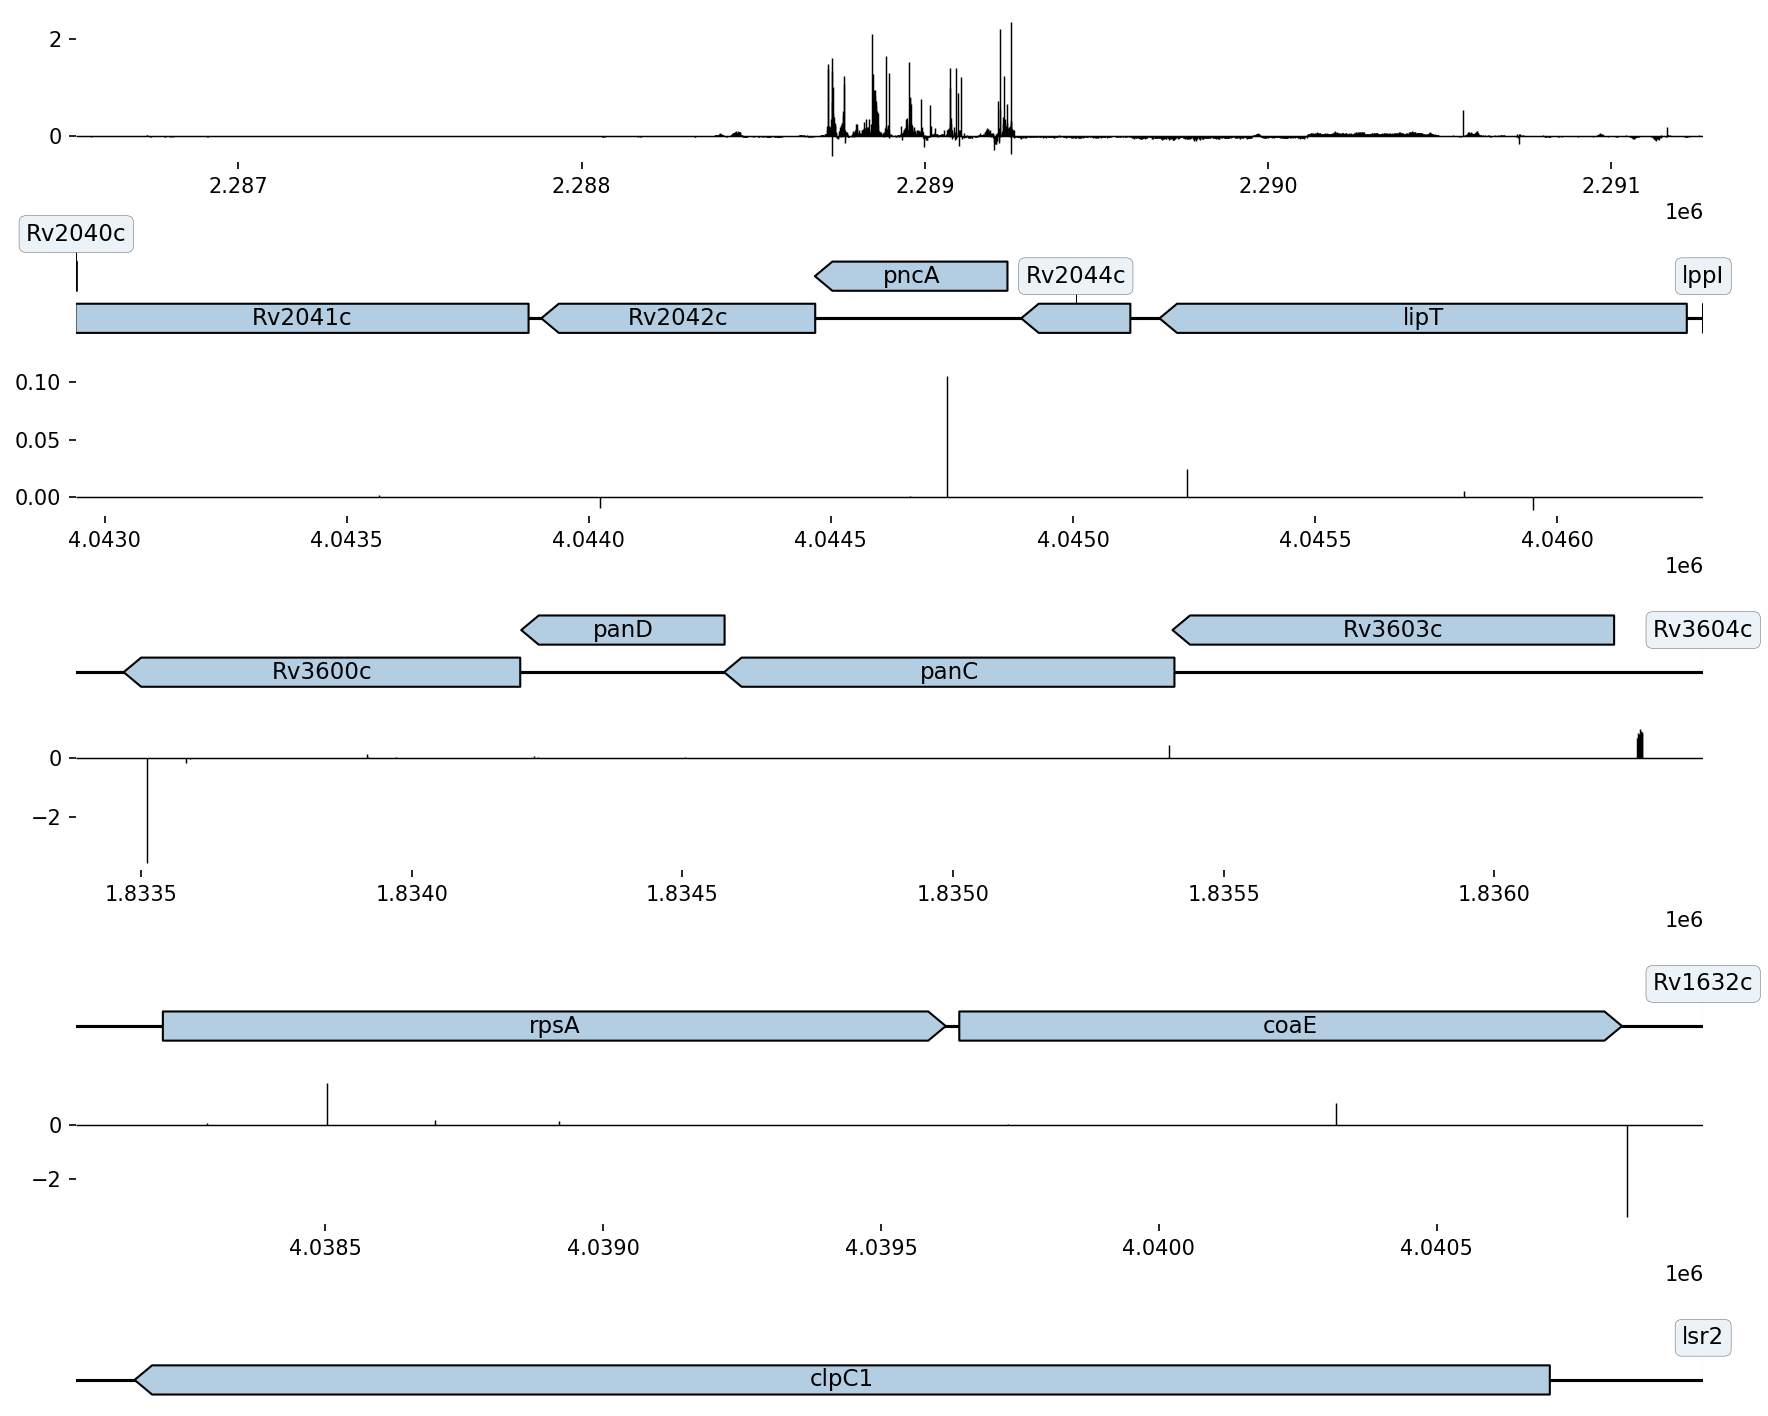

In [2]:
PZA_df, PZA_seqDict = generate_saliency_plots("PZA",
                                              os.path.join(results_path, "PZA_4Loci_peptide_lineage"),
                                              ['pncA', 'panD', 'rpsA', 'clpC1'],
                                              fasta_dir=data_path,
                                              cat_to_check=["1"],
                                              binary=False,
                                              save=True,
                                              significance=True,
                                              sig_thresh=0.05,
                                             )

PZA_scores = sparse.load_npz(os.path.join(results_path, "PZA_4Loci_peptide_lineage/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [239]:
start, end = h37Rv_genes.query("Symbol=='pncA'")[['Start', 'End']].values[0]

# inclusive
start_idx = PZA_df.loc[PZA_df['Pos']==start].index.values[0]
end_idx = PZA_df.loc[PZA_df['Pos']==end].index.values[0]

within_pncA_protein = PZA_df.iloc[end_idx:start_idx+1].reset_index(drop=True)

# exclude pncA_13 - pncA_27 because that isolate's VCF is a little weird. Looks like one real variant is spread over two variants to look like a total insertion of 30 nucleotides, instead of 1
pncA_positive = within_pncA_protein.query("Gene=='pncA' & Max_Sig == 1 & Pos not in ['pncA_13', 'pncA_14', 'pncA_15', 'pncA_16', 'pncA_17', 'pncA_18', 'pncA_19', 'pncA_20', 'pncA_21', 'pncA_22', 'pncA_23', 'pncA_24', 'pncA_25', 'pncA_26', 'pncA_27']")#.reset_index(drop=True)
pncA_negative = within_pncA_protein.query("Gene=='pncA' & Min_Sig == 1 & Pos not in ['pncA_13', 'pncA_14', 'pncA_15', 'pncA_16', 'pncA_17', 'pncA_18', 'pncA_19', 'pncA_20', 'pncA_21', 'pncA_22', 'pncA_23', 'pncA_24', 'pncA_25', 'pncA_26', 'pncA_27']")#.reset_index(drop=True)

# & ~Pos.str.contains('_')")
pncA_positive['Pos'] = pncA_positive['Pos'].astype(str)
pncA_positive = pncA_positive.query("~Pos.str.contains('_')")
pncA_positive['Pos'] = pncA_positive['Pos'].astype(float).astype(int)
pncA_positive.shape

(404, 9)

In [145]:
pncA_positive_site_dict = {'pncA_28': 2289056,
                           'pncA_47': 2288985,
                           'pncA_48': 2288985,
                           'pncA_49': 2288955,
                           'pncA_53': 2288834,
                           'pncA_54': 2288824,
                           'pncA_55': 2288824,
                           'pncA_57': 2288778,
                           'pncA_58': 2288778
                          }

In [238]:
pncA_positive['POS'] = (pncA_positive['Pos'].map(pncA_positive_site_dict).fillna(pncA_positive['Pos'])).astype(float).astype(int)

codon_mapping_dict = dict(zip(np.arange(start, end+1)[::-1], np.sort(list(np.arange(1, 186 + 1 + 1)) * 3)))
pncA_positive['Codon'] = pncA_positive['POS'].map(codon_mapping_dict)

positive_final_df = pd.DataFrame(pncA_positive[['Max', 'Codon']].rename(columns={'Max': 'summed', 'Codon': 'residue'}).groupby('residue')['summed'].sum()).reset_index()
positive_final_df.shape

(159, 2)

In [241]:
pncA_positive['Codon'] = pncA_positive['Pos'].map(codon_mapping_dict)
positive_df_no_indels = pd.DataFrame(pncA_positive[['Max', 'Codon']].rename(columns={'Max': 'summed', 'Codon': 'residue'}).groupby('residue')['summed'].sum()).reset_index()
positive_df_no_indels.shape

(159, 2)

In [250]:
add_nums = list(set(np.arange(185) + 1) - set(positive_df_no_indels.residue))

pd.concat([positive_df_no_indels, pd.DataFrame({'residue': add_nums, 'summed': 0})]).sort_values('residue').to_csv("../structure_annotation/PZA_CNN_with_zeroes/pncA_mutations_positive_saliency.csv", index=False)

In [234]:
positive_final_df

,residue,summed
0,1,0.591338
1,2,0.990494
2,3,0.546385
3,4,1.558665
4,5,0.794217
...,...,...
154,179,0.003685
155,180,0.040572
156,181,0.033130
157,182,0.027067


In [231]:
positive_df_no_indels.summed.min(), positive_df_no_indels.summed.max()

(0.000830112025141716, 3.0535805225372314)

In [232]:
positive_df_no_indels.query("summed==3.0535805225372314")

,residue,summed
146,171,3.053581


In [233]:
positive_final_df.query("summed==3.0535805225372314")

,residue,summed
146,171,3.053581


In [184]:
positive_final_df.summed.min(), positive_final_df.summed.max()

(0.000830112025141716, 3.0535805225372314)

In [185]:
positive_final_df.residue.min(), positive_final_df.residue.max()

(1, 184)

In [197]:
positive_final_df

,residue,summed
0,1,0.591338
1,2,0.990494
2,3,0.546385
3,4,1.558665
4,5,0.794217
...,...,...
154,179,0.003685
155,180,0.040572
156,181,0.033130
157,182,0.027067


In [191]:
pncA_structure_coords.shape

(185, 185)

In [192]:
pncA_structure_coords

array([[ 0.        ,  1.33716641,  4.34877833, ..., 14.71024966,
        16.99048222, 16.51968054],
       [ 1.33716641,  0.        ,  1.32391654, ...,  7.73823869,
        10.26231363, 10.27181829],
       [ 4.34877833,  1.32391654,  0.        , ..., 11.31003081,
        13.21386348, 11.74512175],
       ...,
       [14.71024966,  7.73823869, 11.31003081, ...,  0.        ,
         1.32431001,  4.2731114 ],
       [16.99048222, 10.26231363, 13.21386348, ...,  1.32431001,
         0.        ,  1.33539021],
       [16.51968054, 10.27181829, 11.74512175, ...,  4.2731114 ,
         1.33539021,  0.        ]])

In [195]:
pncA_structure_info

,Unnamed: 0,id,seqres_id,coord_id,one_letter_code,three_letter_code,chain_index,chain_id,sec_struct,sec_struct_3state,hetatm
0,0,1,1,1,M,MET,0,A,C,C,False
1,1,2,2,2,R,ARG,0,A,E,E,False
2,2,3,3,3,A,ALA,0,A,E,E,False
3,3,4,4,4,L,LEU,0,A,E,E,False
4,4,5,5,5,I,ILE,0,A,E,E,False
...,...,...,...,...,...,...,...,...,...,...,...
180,180,181,181,181,E,GLU,0,A,E,E,False
181,181,182,182,182,L,LEU,0,A,E,E,False
182,182,183,183,183,V,VAL,0,A,E,E,False
183,183,184,184,184,C,CYS,0,A,C,C,False


In [196]:
pncA_structure_info.shape

(185, 11)

In [187]:
positive_final_df.to_csv("../structure_annotation/pncA_mutations_positive_saliency.csv", index=False)

In [147]:
pncA_positive

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020,POS
0,pncA,2289241.0,0.149539,0.0,1.0,0.0,0,0,0,2289241
1,pncA,2289240.0,0.181339,0.0,1.0,0.0,0,0,0,2289240
2,pncA,2289239.0,0.260460,0.0,1.0,0.0,0,0,0,2289239
3,pncA,2289238.0,0.646429,0.0,1.0,0.0,0,0,0,2289238
4,pncA,2289237.0,0.148606,0.0,1.0,0.0,0,0,0,2289237
...,...,...,...,...,...,...,...,...,...,...
612,pncA,2288698.0,0.013829,0.0,1.0,0.0,0,0,0,2288698
613,pncA,2288697.0,0.006018,0.0,1.0,0.0,1,0,0,2288697
614,pncA,2288696.0,0.007220,0.0,1.0,0.0,0,0,0,2288696
618,pncA,2288692.0,0.001645,0.0,1.0,0.0,0,0,0,2288692


In [110]:
PZA_df.sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
2487,pncA,pncA_53,2.614851,0.000000,1.0,0.0,0,0,0
2018,pncA,2289251.0,2.356566,0.000000,1.0,0.0,0,0,0
2051,pncA,2289218.0,2.214784,-0.020785,1.0,1.0,1,0,0
2474,pncA,2288847.0,2.095380,0.000000,1.0,0.0,1,0,0
2431,pncA,2288887.0,1.655022,0.000000,1.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...
5484,panD,4045630.0,0.000000,0.000000,0.0,0.0,0,0,0
5485,panD,4045629.0,0.000000,0.000000,0.0,0.0,0,0,0
5486,panD,4045628.0,0.000000,0.000000,0.0,0.0,0,0,0
5487,panD,4045627.0,0.000000,0.000000,0.0,0.0,0,0,0


In [142]:
pncA_positive.query("Pos.str.contains('_') & Pos not in ['pncA_13', 'pncA_14', 'pncA_15', 'pncA_16', 'pncA_17', 'pncA_18', 'pncA_19', 'pncA_20', 'pncA_21', 'pncA_22', 'pncA_23', 'pncA_24', 'pncA_25', 'pncA_26', 'pncA_27']")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
212,pncA,pncA_28,0.103887,0.0,1.0,0.0,0,0,0
302,pncA,pncA_47,0.108246,0.0,1.0,0.0,0,0,0
334,pncA,pncA_49,0.043720,0.0,1.0,0.0,0,0,0
459,pncA,pncA_53,2.614851,0.0,1.0,0.0,0,0,0
470,pncA,pncA_54,0.165239,0.0,1.0,0.0,0,0,0
471,pncA,pncA_55,1.321480,0.0,1.0,0.0,0,0,0
519,pncA,pncA_57,0.183784,0.0,1.0,0.0,0,0,0
520,pncA,pncA_58,0.196121,0.0,1.0,0.0,0,0,0


In [143]:
within_pncA_protein.iloc[334:334+10]

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
334,pncA,pncA_49,0.043720,0.0,1.0,0.0,0,0,0
335,pncA,2288955.0,0.174310,0.0,1.0,0.0,1,0,0
336,pncA,2288954.0,0.225719,0.0,1.0,0.0,0,0,0
337,pncA,2288953.0,1.515773,0.0,1.0,0.0,1,0,0
338,pncA,2288952.0,0.110052,0.0,1.0,0.0,1,0,0
339,pncA,2288951.0,0.034200,0.0,1.0,0.0,0,0,0
340,pncA,2288950.0,0.038797,0.0,1.0,0.0,0,0,0
341,pncA,2288949.0,0.086754,0.0,1.0,0.0,0,0,0
342,pncA,2288948.0,0.358477,0.0,1.0,0.0,0,0,0
343,pncA,2288947.0,0.261285,0.0,1.0,0.0,0,0,0


In [130]:
h37Rv_genes.query("Symbol=='pncA'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
2093,2093,CDS,2288681,2289241,-,0.0,Rv2043c,pncA,Converts amides such as nicotinamide to corres...,Pyrazinamidase/nicotinamidase PncA (PZase),...,I6XD65,"ML1432,ML1432c",MMAR_3016,MSMEG_6506,Mb2069c,NaN,NaN,NaN,NaN,NaN


In [144]:
PZA_isolate_variants.query("POS==2288955")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
43,2288955,T,G,Amb,0.42,pncA,missense_variant,c.287A>C,p.Lys96Thr,NLA009801164,pncA_p.Lys96Thr
44,2288955,T,G,PASS,1.0,pncA,missense_variant,c.287A>C,p.Lys96Thr,NLA009801661,pncA_p.Lys96Thr
46,2288955,T,C,PASS,1.0,pncA,missense_variant,c.287A>G,p.Lys96Arg,NLA009900182,pncA_p.Lys96Arg
113,2288955,TTG,T,PASS,0.99,pncA,frameshift_variant,c.285_286delCA,p.Tyr95fs,Peru3031,pncA_p.Tyr95fs
185,2288955,TTG,T,PASS,1.0,pncA,frameshift_variant,c.285_286delCA,p.Tyr95fs,Peru3342,pncA_p.Tyr95fs
452,2288955,T,TA,PASS,0.98,pncA,frameshift_variant,c.286_287insT,p.Lys96fs,Peru4740,pncA_p.Lys96fs


In [99]:
PZA_isolate_variants.query("Isolate=='Peru4582'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
336,2289040,A,ACGACGAGGAATAGTC,PASS,0.54,pncA,conservative_inframe_insertion,c.187_201dupGACTATTCCTCGTCG,p.Ser67_Trp68insAspTyrSerSerSer,Peru4582,pncA_p.Ser67_Trp68insAspTyrSerSerSer
337,2289057,G,GACGAGGAATAGTCCG,PASS,.,pncA,conservative_inframe_insertion,c.184_185insCGGACTATTCCTCGT,p.Pro62_Asp63insAspTyrSerSerSer,Peru4582,pncA_p.Pro62_Asp63insAspTyrSerSerSer


In [100]:
df_PZA.query("ROLLINGDB_ID=='Peru4582'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,PZA,PZA_lower_bound,PZA_upper_bound,PZA_midpoint,Path,Coll2014,Binary,Lineage,category
642,Peru4582,SAMN05918682,Peru4582,Peru,farhat_internal,NaN,NaN,NJH,m7h10,25-50,25.0,50.0,37.5,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4,0,4,original_test_set


In [102]:
PZA_pred.query("Isolate=='Peru4582'")

,Isolate,y_test,lower,upper,y_pred,compute_error
139,Peru4582,5.228819,25.0,50.0,4.294843,1


In [ ]:
bcftools filter -i "POS >= 2286527 & POS <= 2291268" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Peru4582/pilon/Peru4582.eff.vcf

In [108]:
who_variants.query("mutation.str.contains('AspTyr')")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS


In [36]:
start, end

(2288681, 2289241)

In [23]:
pncA_positive.query("Pos.str.contains('_')")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
2014,pncA,pncA_0,0.851584,0.0,1.0,0.0,0,0,0
2226,pncA,pncA_15,0.027559,0.0,1.0,0.0,0,0,0
2229,pncA,pncA_18,0.022160,0.0,1.0,0.0,0,0,0
2230,pncA,pncA_19,0.008052,0.0,1.0,0.0,0,0,0
2231,pncA,pncA_20,0.028407,0.0,1.0,0.0,0,0,0
2240,pncA,pncA_28,0.103887,0.0,1.0,0.0,0,0,0
2330,pncA,pncA_47,0.108246,0.0,1.0,0.0,0,0,0
2362,pncA,pncA_49,0.043720,0.0,1.0,0.0,0,0,0
2487,pncA,pncA_53,2.614851,0.0,1.0,0.0,0,0,0
2498,pncA,pncA_54,0.165239,0.0,1.0,0.0,0,0,0


In [29]:
PZA_df.iloc[2010:2020]

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
2010,pncA,2289258.0,0.000000,-0.016960,0.0,1.0,0,0,0
2011,pncA,2289257.0,0.000000,-0.005478,0.0,1.0,0,0,0
2012,pncA,2289256.0,0.111045,0.000000,1.0,0.0,0,0,0
2013,pncA,2289255.0,0.135128,0.000000,1.0,0.0,0,0,0
2014,pncA,pncA_0,0.851584,0.000000,1.0,0.0,0,0,0
2015,pncA,2289254.0,0.080305,0.000000,1.0,0.0,0,0,0
2016,pncA,2289253.0,0.129294,0.000000,1.0,0.0,0,0,0
2017,pncA,2289252.0,0.316308,-0.385509,1.0,1.0,0,0,0
2018,pncA,2289251.0,2.356566,0.000000,1.0,0.0,0,0,0
2019,pncA,2289250.0,0.276116,0.000000,1.0,0.0,0,0,0


In [33]:
PZA_isolate_variants.query("POS==2289256")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
126,2289256,T,C,PASS,0.99,pncA-Rv2044c,intergenic_region,n.2289256T>C,.,Peru3056,pncA-Rv2044c_.
229,2289256,T,C,PASS,1.0,pncA-Rv2044c,intergenic_region,n.2289256T>C,.,Peru3405,pncA-Rv2044c_.


In [31]:
PZA_isolate_variants = pd.read_csv(os.path.join(data_path, "PZA", "isolate_variants_fixed_annot.csv"))
df_PZA = pd.read_csv(os.path.join(data_path, "PZA", "data_for_model.csv"))
PZA_pred = pd.read_csv(os.path.join(results_path, "PZA_4Loci_peptide_lineage", "test_predictions.csv"))

In [26]:
pncA_positive

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1,pncA,2291267.0,0.000271,0.000000,1.0,0.0,0,0,0
4,pncA,2291264.0,0.000271,0.000000,1.0,0.0,0,0,0
5,pncA,2291263.0,0.000417,0.000000,1.0,0.0,0,0,0
6,pncA,2291262.0,0.000205,0.000000,1.0,0.0,0,0,0
14,pncA,2291254.0,0.006166,0.000000,1.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...
4603,pncA,2286735.0,0.008814,0.000000,1.0,0.0,0,0,0
4604,pncA,2286734.0,0.007293,0.000000,1.0,0.0,0,0,0
4606,pncA,2286732.0,0.001748,-0.000168,1.0,1.0,0,0,0
4611,pncA,2286727.0,0.001197,-0.000061,1.0,0.0,0,0,0


In [45]:
who_variants.query("mutation=='rpsA_p.Ter482fs'")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS


In [47]:
who_variants.query("mutation.str.contains('rpsA') & mutation.str.contains('c.1445dupG')")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS


In [40]:
# frameshift variant
search_isolates = PZA_seqDict[locus].loc[PZA_seqDict[locus][pos] != ref_nuc].index.values
PZA_seqDict[locus].loc[PZA_seqDict[locus][pos] != ref_nuc]

,2291268.0,2291267.0,2291266.0,2291265.0,2291264.0,2291263.0,2291262.0,2291261.0,2291260.0,2291259.0,...,2286536.0,2286535.0,2286534.0,2286533.0,2286532.0,2286531.0,2286530.0,2286529.0,2286528.0,2286527.0
Isolate,,,,,,,,,,,,,,,,,,,,,
Peru3056,C,C,C,G,A,C,A,G,G,C,...,C,A,A,T,C,C,A,T,G,A
Peru3405,C,C,C,G,A,C,A,G,G,C,...,C,A,A,T,C,C,A,T,G,A


In [41]:
df_PZA.query("ROLLINGDB_ID in @search_isolates")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,PZA,PZA_lower_bound,PZA_upper_bound,PZA_midpoint,Path,Coll2014,Binary,Lineage,category
167,Peru3056,SAMN06010243,Peru3056,Peru,farhat_internal,NaN,NaN,NJH,m7h10,50-100,50.0,100.0,75.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4,0,4,original_test_set
314,Peru3405,SAMN06010358,Peru3405,Peru,farhat_internal,NaN,NaN,NJH,m7h10,>500,500.0,inf,500.0,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4,1,4,original_train_set


In [44]:
df_PZA.query("ROLLINGDB_ID == 'Peru5038'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,PZA,PZA_lower_bound,PZA_upper_bound,PZA_midpoint,Path,Coll2014,Binary,Lineage,category
899,Peru5038,SAMN05916358,Peru5038,Peru,farhat_internal,NaN,NaN,NJH,m7h10,<=25,0.0,25.0,12.5,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.1.1.1,0,4,original_train_set


In [42]:
PZA_pred.query("Isolate in @search_isolates")

,Isolate,y_test,lower,upper,y_pred,compute_error
35,Peru3056,6.228819,50.0,100.0,9.210934,1


In [24]:
who_variants.query("mutation=='pncA_p.Asp136fs'")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
35744,Pyrazinamide,pncA,p.Asp136fs,pncA_p.Asp136fs,1,frameshift,1.0,10.0,9.0,1.0,...,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4,2288776


In [35]:
PZA_isolate_variants.query("Isolate in @ search_isolates & ((POS >= 2286527 & POS <= 2291268) | (POS >= 4038051 & POS <= 4040980) | (POS >= 4042941 & POS <= 4046302) | (POS >= 1833380 & POS <= 1836386)) & EFFECT != 'synonymous_variant' & EFFECT != 'intergenic_region'")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate
1273190,2288834,A,AT,PASS,0.95,pncA,frameshift_variant,c.407dupA,p.Asp136fs,Peru4927
1417643,1834985,T,TG,Amb,0.33,rpsA,frameshift_variant&stop_lost&splice_region_var...,c.1445dupG,p.Ter482fs,Peru5038
1417785,2288834,A,AT,PASS,1.0,pncA,frameshift_variant,c.407dupA,p.Asp136fs,Peru5038
1503875,2288834,A,AT,PASS,0.98,pncA,frameshift_variant,c.407dupA,p.Asp136fs,Peru5136
1612052,2288834,A,AT,PASS,0.98,pncA,frameshift_variant,c.407dupA,p.Asp136fs,Peru4667


In [ ]:
bcftools filter -i "POS >= 2288681 & POS <= 2289241" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/Peru4667/pilon/Peru4667.eff.vcf

In [17]:
PZA_df.iloc[2486:2490]

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
2486,pncA,2288835.0,0.040349,0.0,1.0,0.0,1,0,0
2487,pncA,pncA_53,2.614851,0.0,1.0,0.0,0,0,0
2488,pncA,2288834.0,0.021166,0.0,1.0,0.0,0,0,0
2489,pncA,2288833.0,0.169900,0.0,1.0,0.0,0,0,0


In [ ]:
PZA_df.query("Gene=='pncA' & (Max_Sig == 1 | Min_Sig == 1)")

In [5]:
h37Rv_genes.query("Symbol=='pncA'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
2093,2093,CDS,2288681,2289241,-,0.0,Rv2043c,pncA,Converts amides such as nicotinamide to corres...,Pyrazinamidase/nicotinamidase PncA (PZase),...,I6XD65,"ML1432,ML1432c",MMAR_3016,MSMEG_6506,Mb2069c,NaN,NaN,NaN,NaN,NaN


In [218]:
PZA_df.query("Gene=='rpsA' & (Min_Sig == 1)").sort_values("Min", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
9321,rpsA,1834527.0,0.0,-0.001333,0.0,1.0,0,0,0
9504,rpsA,1834710.0,0.0,-0.001613,0.0,1.0,0,0,0
9489,rpsA,1834695.0,0.0,-0.002243,0.0,1.0,0,0,0
11129,rpsA,1836334.0,0.0,-0.003498,0.0,1.0,0,0,0
9006,rpsA,1834212.0,0.0,-0.003551,0.0,1.0,0,0,0
9172,rpsA,1834378.0,0.0,-0.005722,0.0,1.0,0,0,0
8385,rpsA,1833591.0,0.0,-0.036081,0.0,1.0,0,0,0
8378,rpsA,1833584.0,0.0,-0.173115,0.0,1.0,0,0,0
8305,rpsA,1833511.0,0.0,-3.554094,0.0,1.0,0,0,0


In [219]:
pos = 1833511
locus = 'rpsA'
locus_list = ['pncA', 'panD', 'rpsA', 'clpC1']
locus_idx = locus_list.index(locus)

pos_idx = PZA_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = PZA_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")
print(dict(zip(BASE_TO_COLUMN.keys(), np.max(PZA_scores[:, :, pos_idx, locus_idx], axis=0))))
print(dict(zip(BASE_TO_COLUMN.keys(), np.min(PZA_scores[:, :, pos_idx, locus_idx], axis=0))))

Ref: G
{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}
{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': -3.5540936}


In [221]:
who_variants.query("mutation=='pncA_p.Pro69Ser'")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
36005,Pyrazinamide,pncA,p.Pro69Ser,pncA_p.Pro69Ser,1,missense_variant,1.0,6.0,1.0,5.0,...,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1,2289037


In [220]:
PZA_seqDict[locus].loc[PZA_seqDict[locus][pos]=='-']

,1833380.0,1833381.0,1833382.0,1833383.0,1833384.0,1833385.0,1833386.0,1833387.0,1833388.0,1833389.0,...,1836377.0,1836378.0,1836379.0,1836380.0,1836381.0,1836382.0,1836383.0,1836384.0,1836385.0,1836386.0
Isolate,,,,,,,,,,,,,,,,,,,,,
Peru2961,G,T,G,C,C,G,A,G,C,G,...,C,A,C,G,C,G,C,G,C,T
Peru4986,G,T,G,C,C,G,A,G,C,G,...,C,A,C,G,C,G,C,G,C,T
Peru5020,G,T,G,C,C,G,A,G,C,G,...,C,A,C,G,C,G,C,G,C,T


In [ ]:
bcftools filter -i "POS >= 4038051 & POS <= 4040980" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Peru4687/pilon/Peru4687.eff.vcf

In [ ]:
bcftools filter -i "POS >= 4042941 & POS <= 4046302" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Peru2956/pilon/Peru2956.eff.vcf

In [ ]:
bcftools filter -i "POS >= 1833380 & POS <= 1836386" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/Peru2961/pilon/Peru2961.eff.vcf

In [ ]:
	Start	End
4	1833380	1836386

In [ ]:
	Start	End
3	4038051	4040980

In [192]:
4040704-4038503-1

2200

In [193]:
2200/3

733.3333333333334

In [217]:
who_variants.query("mutation.str.contains('clpC1_c.-1')")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
35150,Pyrazinamide,clpC1,c.-105G>A,clpC1_c.-105G>A,1,upstream_gene_variant,1.0,1.0,0.0,1.0,...,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1,4040599
35152,Pyrazinamide,clpC1,c.-109_-104delACCAGG,clpC1_c.-109_-104delACCAGG,1,upstream_gene_variant,1.0,1.0,0.0,1.0,...,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0,4040595
35187,Pyrazinamide,clpC1,c.-15A>G,clpC1_c.-15A>G,1,upstream_gene_variant,1.0,62.0,11.0,51.0,...,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1,4040689


In [196]:
who_variants.query("mutation.str.contains('clpC1_p.734')")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS


In [ ]:
clpC1_c.

In [183]:
PZA_df.query("Gene=='clpC1' & Min_Sig == 1").sort_values("Min")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
11320,clpC1,4040842.0,0.000000,-3.398635,0.0,1.0,0,0,0
13844,clpC1,4038318.0,0.000000,-0.016654,0.0,1.0,0,0,0
11692,clpC1,4040470.0,0.000000,-0.004137,0.0,1.0,0,0,0
13875,clpC1,4038287.0,0.065724,-0.003513,1.0,1.0,0,0,0
11245,clpC1,4040917.0,0.000000,-0.003459,0.0,1.0,0,0,0


In [3]:
pos = 2289239 # C>T
locus = 'pncA'
locus_list = ['pncA', 'panD', 'rpsA', 'clpC1']
locus_idx = locus_list.index(locus)

pos_idx = PZA_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = PZA_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")
scores = np.max(PZA_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

Ref: G


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.26046032}

In [ ]:
PZA_seqDict[locus].loc[PZA_seqDict[locus][pos] == '-']

# pncA Promoter Variants

In [175]:
who_variants.query("gene=='pncA' & mutation.str.contains('_c.') & confidence.str.contains('Assoc w R')")#.sort_values("genome_index")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
35601,Pyrazinamide,pncA,c.-11A>C,pncA_c.-11A>C,1,upstream_gene_variant,1.0,23.0,23.0,0.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,2289230
35602,Pyrazinamide,pncA,c.-11A>G,pncA_c.-11A>G,1,upstream_gene_variant,1.0,150.0,140.0,10.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,2289230
35603,Pyrazinamide,pncA,c.-11A>T,pncA_c.-11A>T,1,upstream_gene_variant,1.0,4.0,4.0,0.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,NaN,NaN,1,2289230
35604,Pyrazinamide,pncA,c.-12T>C,pncA_c.-12T>C,1,upstream_gene_variant,1.0,8.0,7.0,1.0,...,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4,2289229
35645,Pyrazinamide,pncA,c.-5delG,pncA_c.-5delG,1,upstream_gene_variant,1.0,13.0,10.0,3.0,...,1) Assoc w R,NaN,New AwR,NaN,NaN,yes,NaN,NaN,5,2289236
35651,Pyrazinamide,pncA,c.-7T>C,pncA_c.-7T>C,1,upstream_gene_variant,1.0,3.0,3.0,0.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,NaN,NaN,1,2289234


In [179]:
# add the number to the end of the pncA gene: 2289241
# 11, 12, 5, 7
PZA_df.query("Pos in [2289252, 2289253, 2289246, 2289248]")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
2016,pncA,2289253.0,0.129294,0.000000,1.0,0.0,0,0,0
2017,pncA,2289252.0,0.316308,-0.385509,1.0,1.0,0,0,0
2021,pncA,2289248.0,0.190308,0.000000,1.0,0.0,0,0,0
2023,pncA,2289246.0,0.058541,0.000000,1.0,0.0,0,0,0


In [24]:
pos = 2289246
locus = 'pncA'
locus_list = ['pncA', 'panD', 'rpsA', 'clpC1']
locus_idx = locus_list.index(locus)

pos_idx = PZA_peptide_lineage_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = PZA_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")
scores = np.max(PZA_peptide_lineage_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

Ref: G


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.058540896}

In [ ]:
2289252A>C: 3 (0.316), 

In [ ]:
pos = 2289253
locus = 'pncA'
locus_list = ['pncA', 'panD', 'rpsA', 'clpC1']
locus_idx = locus_list.index(locus)

pos_idx = PZA_peptide_lineage_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = PZA_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")
scores = np.max(PZA_peptide_lineage_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

In [ ]:
PZA_isolate_variants = pd.read_csv(os.path.join(data_path, "PZA", "isolate_variants_fixed_annot.csv"))
df_PZA = pd.read_csv(os.path.join(data_path, "PZA", "data_for_model.csv"))

In [ ]:
solo_results.query("variant=='pncA_c.-11A>G'")

In [ ]:
isolate_lst = PZA_seqDict[locus].loc[PZA_seqDict[locus][2289252]=='G'].index.values
df_PZA.query("ROLLINGDB_ID in @isolate_lst").PZA_upper_bound.value_counts()
# PZA_isolate_variants.query("POS==2289252")#.NUC.value_counts()

In [ ]:
df_PZA.query("ROLLINGDB_ID in @isolate_lst").sort_values("PZA_upper_bound")

In [ ]:
search_lst = PZA_seqDict[locus].loc[PZA_seqDict[locus][2289246]=='-'].index.values

In [ ]:
PZA_isolate_variants.query("Isolate in @search_lst")

In [ ]:
PZA_peptide_lineage_df.query("Gene=='panD' & Max_Sig == 1").sort_values("Max", ascending=False)

In [ ]:
pos = 4045235
locus = 'panD'
locus_list = ['pncA', 'panD', 'rpsA', 'clpC1']
locus_idx = locus_list.index(locus)

pos_idx = PZA_peptide_lineage_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
print(f"Ref: {PZA_seqDict[locus].loc['MT_H37Rv', pos]}")
scores = np.max(PZA_peptide_lineage_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

In [ ]:
(4046118-4045235)/3

In [ ]:
get_codon_from_seq(h37Rv_seq.seq, 295, 4045207, 4046118, '-')

In [ ]:
Seq('GCG').translate(), Seq('GAG').translate()

In [ ]:
h37Rv_genes.query("Symbol=='Rv3603c'")

In [ ]:
(4043862-4044281)/3

In [ ]:
print(who_variants.query("mutation=='pncA_p.Pro69Ser'"))
PZA_peptide_lineage_df.query("Pos==2289037")

In [ ]:
who_variants.query("mutation=='pncA_p.Gln122*'")

In [ ]:
who_variants.query("mutation=='pncA_p.Tyr103*'")

In [ ]:
# pncA_p.Gln122*
pos = 2288878
locus = 'pncA'
locus_list = ['pncA', 'panD', 'rpsA', 'clpC1']
locus_idx = locus_list.index(locus)

pos_idx = PZA_peptide_lineage_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
print(f"Ref: {PZA_seqDict[locus].loc['MT_H37Rv', pos]}")
scores = np.max(PZA_peptide_lineage_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

In [ ]:
# pncA_p.Gln122*
pos = 2288878
locus = 'pncA'
locus_list = ['pncA', 'panD', 'rpsA', 'clpC1']
locus_idx = locus_list.index(locus)

pos_idx = PZA_peptide_lineage_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
print(f"Ref: {PZA_seqDict[locus].loc['MT_H37Rv', pos]}")
scores = np.max(PZA_peptide_lineage_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

In [ ]:
PZA_seqDict[locus].loc[PZA_seqDict[locus][pos] != 'C'][pos]

In [ ]:
# pncA_p.Tyr103*
pos = 2288933
locus = 'pncA'
locus_list = ['pncA', 'panD', 'rpsA', 'clpC1']
locus_idx = locus_list.index(locus)

pos_idx = PZA_peptide_lineage_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
print(f"Ref: {PZA_seqDict[locus].loc['MT_H37Rv', pos]}")
scores = np.max(PZA_peptide_lineage_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

In [ ]:
PZA_seqDict[locus].loc[PZA_seqDict[locus][pos] != 'C'][pos]

In [ ]:
# PZA_isolate_variants = pd.read_csv(os.path.join(data_path, "PZA", "isolate_variants.csv.gz"), compression='gzip')

saliency_dir = os.path.join(results_path, "PZA_4Loci_peptide", "saliency", "quant")
locus_list = yaml.safe_load(open("../config_files/config_pza.yaml", "r"))['locus_list']

# get lineage scores for the primary model
mlp_scores = np.load(os.path.join(saliency_dir, "mlp_scores.npy"))

# create a dataframe with lineages, scores, and average log-MIC of isolates
mlp_scores_df = pd.DataFrame({"position": locus_list, 
                                  "Max": mlp_scores.max(axis=0), 
                                  "Min": mlp_scores.min(axis=0)
                                 })

mlp_scores_paths = glob.glob(os.path.join(saliency_dir, "permutation_test/mlp_scores*.npy"))
assert len(mlp_scores_paths) == 10

mlp_permute_max = [pd.Series(np.load(scores_path).max(axis=0)) for scores_path in mlp_scores_paths]
mlp_permute_max = pd.concat(mlp_permute_max, axis=1).values

mlp_permute_min = [pd.Series(np.load(scores_path).min(axis=0)) for scores_path in mlp_scores_paths]
mlp_permute_min = pd.concat(mlp_permute_min, axis=1).values

for i, row in mlp_scores_df.iterrows():

    # for scores of 0, the p-value is often 0 because all the permuted values are also 0. This is a misleading p-value, so ignore them
    if row["Max"] > 0:
        mlp_scores_df.loc[i, "Max_pval"] = np.mean(mlp_permute_max[i, :] > row["Max"])
    else:
        mlp_scores_df.loc[i, "Max_pval"] = np.nan

    if row["Min"] < 0:
        mlp_scores_df.loc[i, "Min_pval"] = np.mean(mlp_permute_min[i, :] < row["Min"])
    else:
        mlp_scores_df.loc[i, "Min_pval"] = np.nan

In [ ]:
mlp_scores_df

In [ ]:
df_phenos = pd.read_csv(os.path.join(data_path, "PZA", "data_for_model.csv"))
locus_peptide_lengths = pd.read_csv(os.path.join(results_path, "PZA_4Loci", "locus_peptide_lengths.csv"), index_col=[0])

mlp_scores_by_isolate = pd.DataFrame(mlp_scores, index=df_phenos.ROLLINGDB_ID.values)
mlp_scores_by_isolate.columns = [f"{locus}_score" for locus in locus_list]

# .query("pncA_score > 0")
mlp_scores_by_isolate = mlp_scores_by_isolate.sort_values("pncA_score", ascending=False).merge(locus_peptide_lengths, left_index=True, right_index=True)

In [ ]:
mlp_scores_by_isolate.loc[['Peru5149', 'Peru5077']]

In [ ]:
# all samples with a nonzero score for rpsA have the frameshift variant
mlp_scores_by_isolate.query('rpsA_score != 0').rpsA_length.unique(), mlp_scores_by_isolate.query('rpsA_score == 0').rpsA_length.unique()

In [ ]:
# 1834985_insG not have any non-zero saliency scores, so all the prediction is coming from the rpsA peptide length
pos = 'rpsA_0'
locus = 'rpsA'
locus_list = ['pncA', 'panD', 'rpsA', 'clpC1']
locus_idx = locus_list.index(locus)

pos_idx = PZA_peptide_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
print(f"Ref: {PZA_seqDict[locus].loc['MT_H37Rv', pos]}")
max_scores = np.max(PZA_peptide_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores))

In [ ]:
locus_peptide_lengths[f"{locus}_length"].argmax()

In [ ]:
locus = 'rpsA'
# say that because most (1008/1015, 99.3 %) of samples have lengths >= 1200, model probably didn't learn well enough about the relationship below that threshold
# 5/7 of the weird samples have positive saliency scores so still associated with R. Though I can't explain the other 2
sns.scatterplot(data=mlp_scores_by_isolate,
                x=f'{locus}_length',
                y=f'{locus}_score',
               )

# plt.axvline(1506, color='black', linestyle='--', linewidth=1, zorder=0)
plt.title(f"{locus} Locus Peptide Total Length vs. Saliency Score")
ref_len = int(locus_peptide_lengths[f"{locus}_length"].mode().values[0])
plt.xlabel(f"Length (H37Rv = {ref_len})")
plt.ylabel("Saliency Score")
sns.despine()
plt.show()

In [ ]:
st.pearsonr(mlp_scores_by_isolate[f"{locus}_length"], mlp_scores_by_isolate[f"{locus}_score"])

In [ ]:
locus = 'pncA'
# say that because most (1008/1015, 99.3 %) of samples have lengths >= 1200, model probably didn't learn well enough about the relationship below that threshold
# 5/7 of the weird samples have positive saliency scores so still associated with R. Though I can't explain the other 2
sns.scatterplot(data=mlp_scores_by_isolate,
                x=f'{locus}_length',
                y=f'{locus}_score',
               )

# plt.axvline(1506, color='black', linestyle='--', linewidth=1, zorder=0)
plt.title(f"{locus} Locus Peptide Total Length vs. Saliency Score")
ref_len = int(locus_peptide_lengths[f"{locus}_length"].mode().values[0])
plt.xlabel(f"Length (H37Rv = {ref_len})")
plt.ylabel("Saliency Score")
sns.despine()
plt.show()

In [ ]:
st.spearmanr(mlp_scores_by_isolate[f"{locus}_length"], mlp_scores_by_isolate[f"{locus}_score"])

In [ ]:
# full length or nonsense mutations
st.pearsonr(mlp_scores_by_isolate.query(f'{locus}_length < 1506')[f'{locus}_length'],
             mlp_scores_by_isolate.query(f'{locus}_length < 1506')[f'{locus}_score']
            )

In [ ]:
PZA_saliency_variants_df = extract_saliency_score_variant_types(PZA_lineage_df, PZA_seqDict, PZA_lineage_scores, max_scores=True)

In [ ]:
# pos = "pncA_28"
# gene = "pncA"
# pos_idx = list(PZA_seqDict[gene].columns).index(pos)
# gene_idx = list(PZA_seqDict.keys()).index(gene)

# print(f"Ref: {PZA_seqDict[gene].loc['MT_H37Rv', pos]}")
# # max_scores = np.max(PZA_lineage_scores[:, :, pos_idx, gene_idx], axis=0)
# # dict(zip(BASE_TO_COLUMN.keys(), max_scores))

# scores_df = pd.DataFrame({"Nuc": BASE_TO_COLUMN.keys(), "Score": np.max(PZA_lineage_scores[:, :, pos_idx, gene_idx], axis=0)})
# scores_df

# Rifampicin

2 loci!
Plotting significant saliency scores for rpoBC using 10 max scores and 10 min scores
Plotting significant saliency scores for rpoA using 10 max scores and 10 min scores
15 Cat 1 WHO catalog sites for RIF
2 Cat 1 WHO catalog sites not found
Sites not found: [760314 761138]


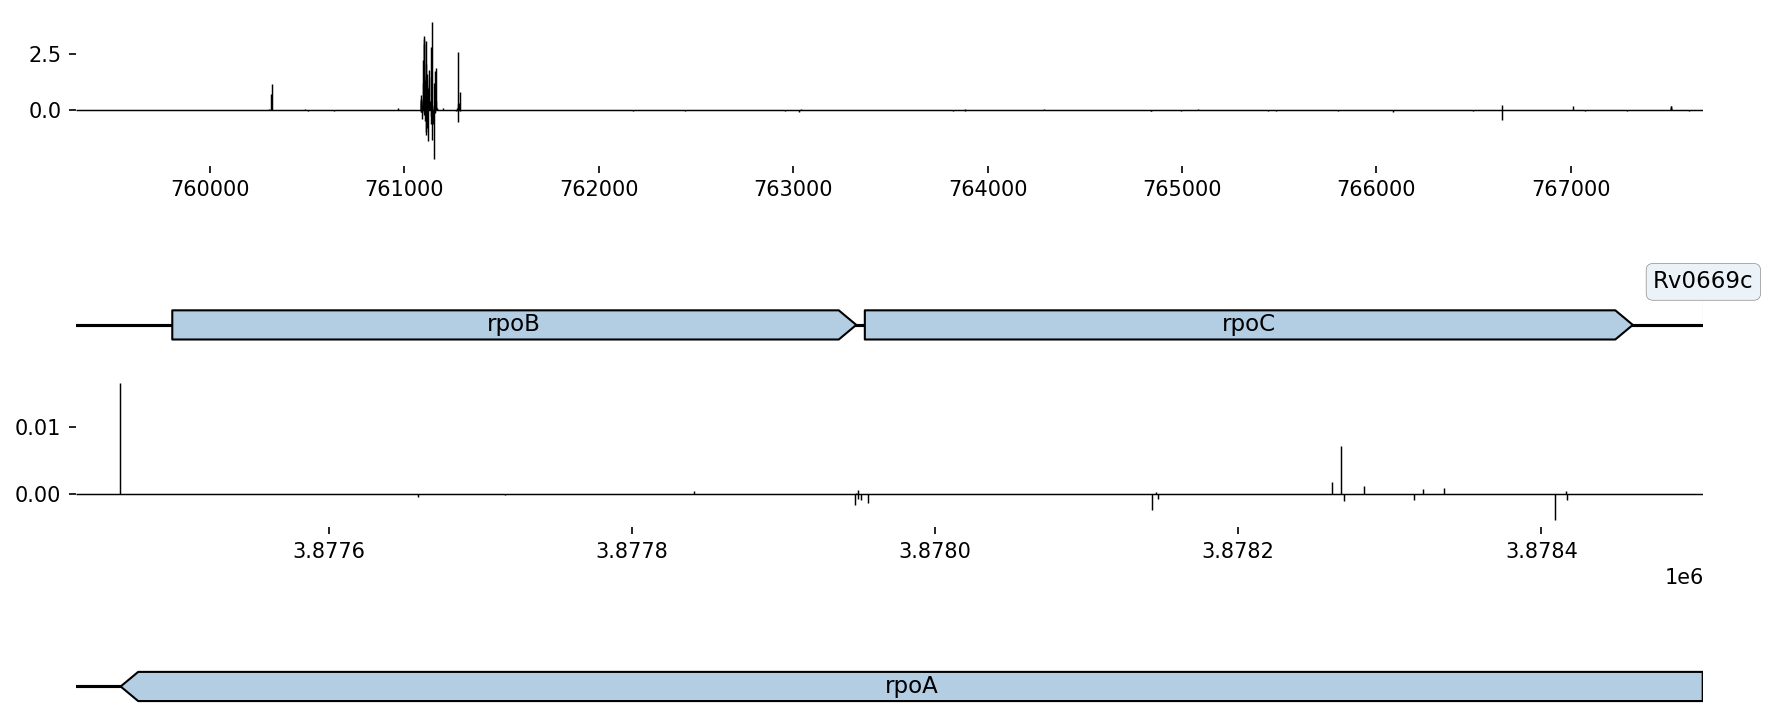

In [2]:
RIF_df, rpoABC_seqDict = generate_saliency_plots(drug="RIF",
                                                out_dir=os.path.join(results_path, "RIF_rpoABC_peptide_lineage"),
                                                locus_list=["rpoBC", "rpoA"],
                                                fasta_dir=data_path,
                                                cat_to_check=["1"],
                                                binary=False,
                                                save=True,
                                                significance=True,
                                                sig_thresh=0.05,
                                              )


RIF_scores = sparse.load_npz(os.path.join(results_path, "RIF_rpoABC_peptide_lineage/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [3]:
# Ser441Gln: 761127  TCG > CAG
pos = 761127
locus = 'rpoBC'
locus_list = ['rpoBC', 'rpoA']
locus_idx = locus_list.index(locus)

pos_idx = RIF_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = rpoABC_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")

# both of these have the same effect, rpoC_p.Glu1092Asp
print(dict(zip(BASE_TO_COLUMN.keys(), np.max(RIF_scores[:, :, pos_idx, locus_idx], axis=0))))
print(dict(zip(BASE_TO_COLUMN.keys(), np.min(RIF_scores[:, :, pos_idx, locus_idx], axis=0))))

Ref: T
{'A': 0.0, 'C': 0.08409664, 'T': 0.0, 'G': 0.052705813, '-': 0.0}
{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}


In [11]:
Seq("TCG").translate(), Seq("CAG").translate()

(Seq('S'), Seq('Q'))

In [4]:
# Ser441Gln: 761127  TCG > CAG
pos = 761128
locus = 'rpoBC'
locus_list = ['rpoBC', 'rpoA']
locus_idx = locus_list.index(locus)

pos_idx = RIF_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = rpoABC_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")

# both of these have the same effect, rpoC_p.Glu1092Asp
print(dict(zip(BASE_TO_COLUMN.keys(), np.max(RIF_scores[:, :, pos_idx, locus_idx], axis=0))))
print(dict(zip(BASE_TO_COLUMN.keys(), np.min(RIF_scores[:, :, pos_idx, locus_idx], axis=0))))

Ref: C
{'A': 0.0, 'C': 0.0, 'T': 1.7755951, 'G': 1.1447242, '-': 0.0}
{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}


In [67]:
RIF_isolate_variants = pd.read_csv(os.path.join(data_path, "RIF", "isolate_variants_fixed_annot.csv"))
df_RIF = pd.read_csv(os.path.join(data_path, "RIF", "data_for_model.csv"))

In [18]:
RIF_df.sort_values("Max", ascending=False).head(10)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1903,rpoBC,761140.0,3.953081,-1.343319,1.0,1.0,1,0,0
1860,rpoBC,rpoBC_67,3.917845,0.000000,1.0,0.0,0,0,0
1859,rpoBC,761102.0,3.320427,0.000000,1.0,0.0,0,0,0
1858,rpoBC,761101.0,3.183172,0.000000,1.0,0.0,1,0,0
1873,rpoBC,761110.0,3.115016,-0.965081,1.0,1.0,1,0,0
1854,rpoBC,rpoBC_64,3.054623,0.000000,1.0,0.0,0,0,0
1861,rpoBC,rpoBC_68,3.005604,0.000000,1.0,0.0,0,0,0
1857,rpoBC,761100.0,2.955752,-0.214053,1.0,1.0,1,0,0
1902,rpoBC,761139.0,2.813242,-0.283314,1.0,1.0,1,0,0
2040,rpoBC,761277.0,2.592253,-0.548590,1.0,1.0,1,0,0


In [79]:
RIF_isolate_variants.query("Isolate in @search_isolates")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
2,761140,A,G,PASS,1.0,rpoB,missense_variant,c.1334A>G,p.His445Arg,1726,rpoB_p.His445Arg
3,762910,T,C,PASS,1.0,rpoB,missense_variant,c.3104T>C,p.Ile1035Thr,1726,rpoB_p.Ile1035Thr
14,760115,C,T,PASS,0.98,rpoB,synonymous_variant,c.309C>T,p.Asp103Asp,1753,rpoB_c.309C>T
15,761139,C,T,PASS,1.0,rpoB,missense_variant,c.1333C>T,p.His445Tyr,1753,rpoB_p.His445Cys
16,761140,A,G,PASS,1.0,rpoB,missense_variant,c.1334A>G,p.His445Arg,1753,rpoB_p.His445Cys
...,...,...,...,...,...,...,...,...,...,...,...
16377,763031,T,C,PASS,1.0,rpoB,synonymous_variant,c.3225T>C,p.Ala1075Ala,TDR10S168L002,rpoB_c.3225T>C
16411,760115,C,T,PASS,1.0,rpoB,synonymous_variant,c.309C>T,p.Asp103Asp,TDR73S150L002,rpoB_c.309C>T
16412,761140,A,G,PASS,1.0,rpoB,missense_variant,c.1334A>G,p.His445Arg,TDR73S150L002,rpoB_p.His445Arg
16431,761090,C,G,PASS,1.0,rpoB,missense_variant,c.1284C>G,p.Ser428Arg,TDR13S110L002,rpoB_p.Ser428Arg


In [72]:
# rpoC_c.3643C>T predicted MIC = 0.14 in in silico mutagenesis
pos = 761140
locus = 'rpoBC'
locus_list = ['rpoBC', 'rpoA']
locus_idx = locus_list.index(locus)

pos_idx = RIF_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = rpoABC_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")

# both of these have the same effect, rpoC_p.Glu1092Asp
print(dict(zip(BASE_TO_COLUMN.keys(), np.max(RIF_scores[:, :, pos_idx, locus_idx], axis=0))))
print(dict(zip(BASE_TO_COLUMN.keys(), np.min(RIF_scores[:, :, pos_idx, locus_idx], axis=0))))

Ref: A
{'A': 0.0, 'C': 1.7310834, 'T': 1.0964767, 'G': 3.9530807, '-': 0.0}
{'A': 0.0, 'C': -1.3433189, 'T': 0.0, 'G': 0.0, '-': 0.0}


In [ ]:
761140A>G (rpoB_p.His445Arg, Group 1). 

In [81]:
Seq("CAC").translate(), Seq("CCC").translate(), Seq("CTC").translate(), Seq("CGC").translate()

(Seq('H'), Seq('P'), Seq('L'), Seq('R'))

In [82]:
who_variants.query("mutation.str.contains('rpoB_p.His445')")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
41141,Rifampicin,rpoB,p.His445_Lys446del,rpoB_p.His445_Lys446del,1,inframe_deletion,1.0,1.0,1.0,0.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,RRDR,NaN,1,761139
41142,Rifampicin,rpoB,p.His445_Lys446delinsGln,rpoB_p.His445_Lys446delinsGln,1,inframe_deletion,0.0,0.0,0.0,0.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,RRDR,NaN,1,761139
41143,Rifampicin,rpoB,p.His445Arg,rpoB_p.His445Arg,1,missense_variant,1.0,107.0,105.0,2.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,761140
41144,Rifampicin,rpoB,p.His445Asn,rpoB_p.His445Asn,1,missense_variant,1.0,104.0,35.0,69.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,Borderline,NaN,1,761139
41145,Rifampicin,rpoB,p.His445Asp,rpoB_p.His445Asp,1,missense_variant,1.0,574.0,565.0,9.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,761139
41146,Rifampicin,rpoB,p.His445Cys,rpoB_p.His445Cys,1,missense_variant,1.0,71.0,65.0,6.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,761139
41147,Rifampicin,rpoB,p.His445Gln,rpoB_p.His445Gln,1,missense_variant,1.0,2.0,0.0,2.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,RRDR,NaN,1,761141
41148,Rifampicin,rpoB,p.His445Gly,rpoB_p.His445Gly,1,missense_variant,1.0,10.0,7.0,3.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,RRDR,NaN,1,761139
41149,Rifampicin,rpoB,p.His445Leu,rpoB_p.His445Leu,1,missense_variant,1.0,210.0,192.0,18.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,761140
41150,Rifampicin,rpoB,p.His445Phe,rpoB_p.His445Phe,1,missense_variant,1.0,2.0,2.0,0.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,RRDR,NaN,1,761139


In [78]:
search_isolates = rpoABC_seqDict[locus].loc[rpoABC_seqDict[locus][pos] == 'G'].index.values
rpoABC_seqDict[locus].loc[rpoABC_seqDict[locus][pos] == 'G']

,759310.0,759311.0,759312.0,759313.0,759314.0,759315.0,759316.0,759317.0,759318.0,759319.0,...,767674.0,767675.0,767676.0,767677.0,767678.0,767679.0,767680.0,767681.0,767682.0,767683.0
Isolate,,,,,,,,,,,,,,,,,,,,,
ERR4810790,T,C,G,A,T,T,C,G,A,C,...,G,G,C,C,G,C,C,G,A,G
ERR4810925,T,C,G,A,T,T,C,G,A,C,...,G,G,C,C,G,C,C,G,A,G
ERR4811380,T,C,G,A,T,T,C,G,A,C,...,G,G,C,C,G,C,C,G,A,G
ERR4822313,T,C,G,A,T,T,C,G,A,C,...,G,G,C,C,G,C,C,G,A,G
ERR4831241,T,C,G,A,T,T,C,G,A,C,...,G,G,C,C,G,C,C,G,A,G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TDR34S89L002,T,C,G,A,T,T,C,G,A,C,...,G,G,C,C,G,C,C,G,A,G
TDR73S150L002,T,C,G,A,T,T,C,G,A,C,...,G,G,C,C,G,C,C,G,A,G
SAMEA3558111,T,C,G,A,T,T,C,G,A,C,...,G,G,C,C,G,C,C,G,A,G


In [80]:
RIF_df.query("Pos==@pos")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1903,rpoBC,761140.0,3.953081,-1.343319,1.0,1.0,1,0,0


In [21]:
RIF_df.iloc[1857:]

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1857,rpoBC,761100.0,2.955752,-0.214053,1.0,1.0,1,0,0
1858,rpoBC,761101.0,3.183172,0.000000,1.0,0.0,1,0,0
1859,rpoBC,761102.0,3.320427,0.000000,1.0,0.0,0,0,0
1860,rpoBC,rpoBC_67,3.917845,0.000000,1.0,0.0,0,0,0
1861,rpoBC,rpoBC_68,3.005604,0.000000,1.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...
9600,rpoA,3877437.0,0.000000,0.000000,0.0,0.0,0,0,0
9601,rpoA,3877436.0,0.000000,0.000000,0.0,0.0,0,0,0
9602,rpoA,3877435.0,0.000000,0.000000,0.0,0.0,0,0,0
9603,rpoA,3877434.0,0.000000,0.000000,0.0,0.0,0,0,0


In [17]:
759807 + 450 * 3

761157

In [16]:
Seq("ACA").translate(), Seq("TCA").translate(), Seq("GCA").translate()

(Seq('T'), Seq('S'), Seq('A'))

In [11]:
(pos - 759807) / 3

444.3333333333333

In [9]:
h37Rv_genes.query("Symbol=='rpoB'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
687,687,CDS,759807,763325,+,0.0,Rv0667,rpoB,Catalyzes the transcription of DNA into RNA us...,DNA-directed RNA polymerase (beta chain) RpoB ...,...,P9WGY9,"ML1891,ML1891c",MMAR_0995,MSMEG_1367,Mb0686,NaN,NaN,NaN,NaN,NaN


In [13]:
who_variants.query("mutation.str.contains('rpoB') & mutation.str.contains('444')")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
41475,Rifampicin,rpoB,p.Thr444dup,rpoB_p.Thr444dup,1,inframe_insertion,1.0,10.0,10.0,0.0,...,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4,761138
41476,Rifampicin,rpoB,p.Thr444Ile,rpoB_p.Thr444Ile,1,missense_variant,0.0,0.0,0.0,0.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,RRDR,NaN,1,761137
41477,Rifampicin,rpoB,p.Thr444Pro,rpoB_p.Thr444Pro,1,missense_variant,0.0,0.0,0.0,0.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,RRDR,NaN,1,761136
41478,Rifampicin,rpoB,p.Thr444Ser,rpoB_p.Thr444Ser,1,missense_variant,0.0,0.0,0.0,0.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,RRDR,NaN,1,761136


In [129]:
# rpoC_c.3643C>T predicted MIC = 0.14 in in silico mutagenesis
pos = 766645
locus = 'rpoBC'
locus_list = ['rpoBC', 'rpoA']
locus_idx = locus_list.index(locus)

pos_idx = ≈.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = rpoABC_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")

# both of these have the same effect, rpoC_p.Glu1092Asp
print(dict(zip(BASE_TO_COLUMN.keys(), np.max(RIF_scores[:, :, pos_idx, locus_idx], axis=0))))
print(dict(zip(BASE_TO_COLUMN.keys(), np.min(RIF_scores[:, :, pos_idx, locus_idx], axis=0))))

Ref: A
{'A': 0.0, 'C': 0.0, 'T': 0.22564349, 'G': 0.0, '-': 0.0}
{'A': 0.0, 'C': -0.4641123, 'T': 0.0, 'G': 0.0, '-': 0.0}


In [172]:
RIF_df.query("Gene=='rpoA'").sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
9575,rpoA,3877462.0,0.016407,0.0,1.0,0.0,0,0,0
8769,rpoA,3878268.0,0.007120,0.0,1.0,0.0,0,0,0
8775,rpoA,3878262.0,0.001869,0.0,1.0,0.0,0,0,0
8754,rpoA,3878283.0,0.001261,0.0,1.0,0.0,0,0,0
8701,rpoA,3878336.0,0.001002,0.0,1.0,0.0,0,0,0
...,...,...,...,...,...,...,...,...,...
8901,rpoA,3878136.0,0.000000,0.0,0.0,0.0,0,0,0
8902,rpoA,3878135.0,0.000000,0.0,0.0,0.0,0,0,0
8903,rpoA,3878134.0,0.000000,0.0,0.0,0.0,0,0,0
8904,rpoA,3878133.0,0.000000,0.0,0.0,0.0,0,0,0


In [174]:
# rpoC_c.3643C>T predicted MIC = 0.14 in in silico mutagenesis
pos = 3877462
locus = 'rpoA'
locus_list = ['rpoBC', 'rpoA']
locus_idx = locus_list.index(locus)

pos_idx = RIF_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = rpoABC_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")

# both of these have the same effect, rpoC_p.Glu1092Asp
print(dict(zip(BASE_TO_COLUMN.keys(), np.max(RIF_scores[:, :, pos_idx, locus_idx], axis=0))))
print(dict(zip(BASE_TO_COLUMN.keys(), np.min(RIF_scores[:, :, pos_idx, locus_idx], axis=0))))

Ref: C
{'A': 0.016407311, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}
{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}


In [133]:
Seq("GAA").translate(), Seq("GAT").translate(), Seq("GAC").translate(), Seq("GAG").translate()

(Seq('E'), Seq('D'), Seq('D'), Seq('E'))

In [ ]:
rpoC_c.3276A>T (H37Rv position 766645) 

In [134]:
search_isolates = rpoABC_seqDict[locus].loc[rpoABC_seqDict[locus][pos] == 'T'].index.values
len(search_isolates)

1

In [137]:
search_isolates = rpoABC_seqDict[locus].loc[rpoABC_seqDict[locus][pos] == 'C'].index.values
len(search_isolates)

264

In [94]:
# rpoC_c.3643C>T predicted MIC = 0.14 in in silico mutagenesis
pos = 767012 #766645 #
locus = 'rpoBC'
locus_list = ['rpoBC', 'rpoA']
locus_idx = locus_list.index(locus)

pos_idx = RIF_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = rpoABC_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")
scores = np.max(RIF_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

Ref: C


{'A': 0.0, 'C': 0.0, 'T': 0.18833409, 'G': 0.0, '-': 0.0}

In [57]:
rpoC_c.3276A>T (268 isolates) and rpoC_c.3643C>T (3 RIF-susceptible isolates)

SyntaxError: invalid syntax (434619916.py, line 1)

In [58]:
763370 + 3276 - 1, 763370 + 3643 - 1

(766645, 767012)

In [99]:
763370+1092*3

766646

In [93]:
pd.DataFrame(df_RIF.groupby('Coll2014')['RIF_midpoint'].mean()).sort_values('RIF_midpoint', ascending=False).query("Coll2014=='2.2.1'")

,RIF_midpoint
Coll2014,
2.2.1,3.850271


In [95]:
search_isolates = rpoABC_seqDict[locus].loc[rpoABC_seqDict[locus][pos] != ref_nuc].index.values
len(search_isolates)

3

In [96]:
df_RIF.query("ROLLINGDB_ID in @search_isolates")[['Coll2014', 'Binary']].value_counts()

Coll2014  Binary
2.2.1     0         3
Name: count, dtype: int64

In [97]:
df_RIF.query("ROLLINGDB_ID in @search_isolates")['Binary'].sum()

0

In [88]:
172/268

0.6417910447761194

In [70]:
df_RIF_test_pred = pd.read_csv(os.path.join(results_path, "RIF_rpoABC_peptide_lineage", "test_predictions.csv"))

In [84]:
df_RIF_test_pred.query("Isolate in @search_isolates").compute_error.mean()

0.23076923076923078

In [21]:
df_RIF = pd.read_csv(os.path.join(data_path, "RIF", "data_for_model.csv"))

In [16]:
RIF_df.query("Pos in [760314, 761138]")

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
1041,rpoBC,760314.0,0.000000,0.00000,0.0,0.0,1,0,0
1901,rpoBC,761138.0,0.149606,-0.32898,1.0,1.0,1,0,0


In [4]:
# Val170Phe is predicted to have a very large MIC though
pos = 760314
locus = 'rpoBC'
locus_list = ['rpoBC', 'rpoA']
locus_idx = locus_list.index(locus)

pos_idx = RIF_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = rpoABC_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")
scores = np.max(RIF_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

Ref: G


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}

In [15]:
rpoABC_seqDict[locus].loc[rpoABC_seqDict[locus][pos] != ref_nuc][pos]

Isolate
ERR4811605        T
ERR4822345        T
ERR4797028        T
ERR4797289        T
ERR4797481        T
ERR4813032        T
ERR4813206        T
ERR3287600        T
ERR3287675        T
ERR2184309        T
ERR4828815        T
ERR4828894        T
ERR2510621        T
ERR2510647        T
ERR4829932        T
Peru4574          T
Peru4693          T
Peru4915          T
Peru4921          T
Peru4972          T
TDR170S177L002    T
SAMEA3558142      T
SAMEA3558189      T
Name: 760314.0, dtype: object

In [6]:
df_RIF = pd.read_csv(os.path.join(data_path, "RIF", "data_for_model.csv"))
RIF_isolate_variants = pd.read_csv(os.path.join(data_path, "RIF", "isolate_variants_fixed_annot.csv"))

In [11]:
search_isolates = RIF_isolate_variants.query("mutation.str.contains('Val170') & Isolate in @df_RIF.ROLLINGDB_ID.values").Isolate.values
RIF_isolate_variants.query("mutation.str.contains('Val170') & Isolate in @df_RIF.ROLLINGDB_ID.values")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
175,760314,G,T,PASS,1.0,rpoB,missense_variant,c.508G>T,p.Val170Phe,ERR2184309,rpoB_p.Val170Phe
1470,760314,G,T,PASS,1.0,rpoB,missense_variant,c.508G>T,p.Val170Phe,ERR2510621,rpoB_p.Val170Phe
1551,760314,G,T,PASS,1.0,rpoB,missense_variant,c.508G>T,p.Val170Phe,ERR2510647,rpoB_p.Val170Phe
1977,760314,G,T,PASS,1.0,rpoB,missense_variant,c.508G>T,p.Val170Phe,ERR3287600,rpoB_p.Val170Phe
2055,760314,G,T,PASS,1.0,rpoB,missense_variant,c.508G>T,p.Val170Phe,ERR3287675,rpoB_p.Val170Phe
3675,760314,G,T,PASS,1.0,rpoB,missense_variant,c.508G>T,p.Val170Phe,ERR4797028,rpoB_p.Val170Phe
4092,760314,G,T,PASS,0.99,rpoB,missense_variant,c.508G>T,p.Val170Phe,ERR4797289,rpoB_p.Val170Phe
4421,760314,G,T,PASS,1.0,rpoB,missense_variant,c.508G>T,p.Val170Phe,ERR4797481,rpoB_p.Val170Phe
4895,760315,T,C,PASS,1.0,rpoB,missense_variant,c.509T>C,p.Val170Ala,ERR4797828,rpoB_p.Val170Ala
5659,760315,T,C,PASS,1.0,rpoB,missense_variant,c.509T>C,p.Val170Ala,ERR4810479,rpoB_p.Val170Ala


In [12]:
df_RIF.query("ROLLINGDB_ID in @search_isolates")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,RIF,RIF_lower_bound,RIF_midpoint,RIF_upper_bound,RIF_quality,Path,Coll2014,Binary,Lineage,category
48,ERR4810981,ERS5300699,site.02.subj.0058.lab.22A008.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>4.0,4.0,4.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,1,2,original_test_set
163,ERR4810843,ERS5300561,site.02.subj.0190.lab.2013222078.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,2.0,1.0,1.5,2.0,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,1,2,original_train_set
626,ERR4810479,ERS5298506,site.02.subj.0886.lab.22A120.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>4.0,4.0,4.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.2,1,2,original_train_set
777,ERR4811605,ERS5301320,site.02.subj.1147.lab.2014185084.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>4.0,4.0,4.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,1,2,original_test_set
1400,ERR4822345,ERS5312409,site.03.subj.JPN-R2012-00013.lab.03-JPN-R2012-...,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>4.0,4.0,4.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.4.2,1,4,original_train_set
2158,ERR4797028,ERS5282044,site.04.subj.00707.lab.713695.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>4.0,4.0,4.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,1.1.2,1,1,original_train_set
2404,ERR4797289,ERS5282312,site.04.subj.01015.lab.716209.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>4.0,4.0,4.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1.1,1,2,original_train_set
2484,ERR4797828,ERS5282854,site.04.subj.01110.lab.719927.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,4.0,2.0,3.0,4.0,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.8,1,4,original_train_set
2659,ERR4797481,ERS5282505,site.04.subj.01353.lab.721678.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>4.0,4.0,4.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,3,1,3,original_train_set
3331,ERR4813032,ERS5303192,site.05.subj.LR-2419.lab.FN-00641-18.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,>8.0,8.0,8.0,inf,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.1.1.3,1,4,original_train_set


In [9]:
pos = 761138
locus = 'rpoBC'
locus_list = ['rpoBC', 'rpoA']
locus_idx = locus_list.index(locus)

pos_idx = RIF_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
ref_nuc = rpoABC_seqDict[locus].loc['MT_H37Rv', pos]
print(f"Ref: {ref_nuc}")
scores = np.min(RIF_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

Ref: C


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': -0.6337456, '-': 0.0}

In [17]:
who_variants.query("drug=='Rifampicin' & POS==761138")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
40164,Rifampicin,rpoB,c.1332C>T,rpoB_c.1332C>T,1,synonymous_variant,1.0,NaN,NaN,NaN,...,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0,761138
41475,Rifampicin,rpoB,p.Thr444dup,rpoB_p.Thr444dup,1,inframe_insertion,1.0,10.0,10.0,0.0,...,1) Assoc w R,NaN,UP from AwRI to AwR,NaN,NaN,yes,NaN,NaN,4,761138


In [ ]:
RIF_rpoABC_lineage_df.query("Gene=='rpoA' & Min_Sig == 1").sort_values("Min").head()

In [ ]:
rpoABC_seqDict['rpoA'].loc[rpoABC_seqDict['rpoA'][3877482]=='T']

In [ ]:
rpoABC_seqDict['rpoA'][3877482].value_counts()

In [ ]:
df_RIF = pd.read_csv(os.path.join(data_path, "RIF", "data_for_model.csv"))
RIF_isolate_variants = pd.read_csv(os.path.join(data_path, "RIF", "isolate_variants_fixed_annot.csv"))

In [ ]:
df_RIF.query("ROLLINGDB_ID=='ERR4811561'")

In [ ]:
df_RIF.query("RIF=='<=0.06'")

In [ ]:
RIF_isolate_variants.query("Isolate=='ERR4811561'")

# Moxifloxacin

1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores
14 Cat 1/2 WHO catalog sites for MXF
1 Cat 1/2 WHO catalog sites not found
Sites not found: [7564]


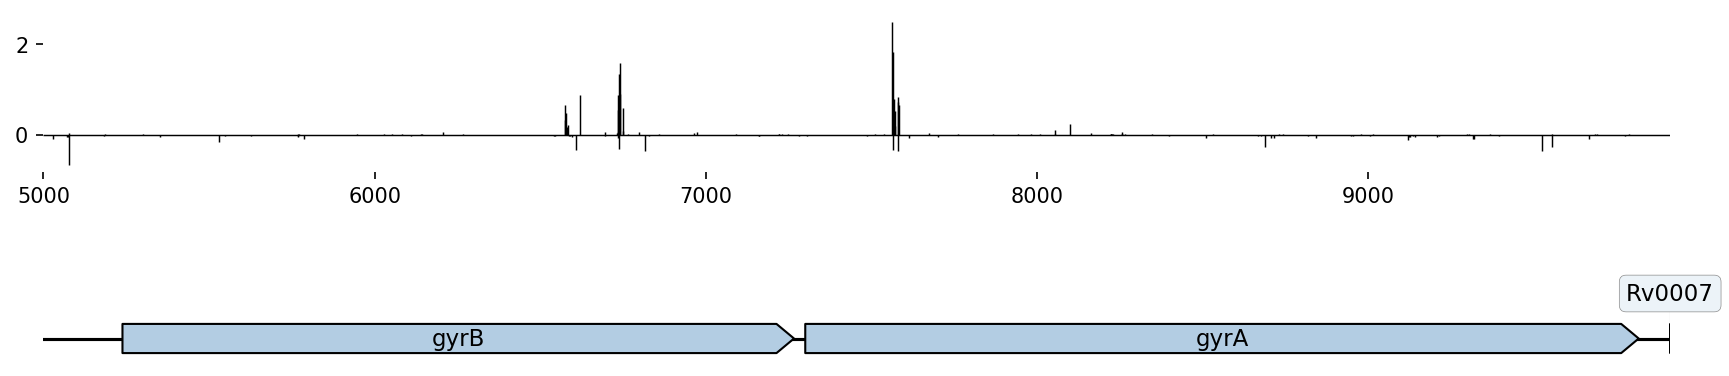

In [53]:
MXF_df, MXF_gyrBA_seqDict = generate_saliency_plots(drug="MXF",
                                                    out_dir=os.path.join(results_path, "MXF_gyrBA_peptide_lineage"),
                                                    locus_list=["gyrBA"],
                                                    fasta_dir=data_path,
                                                    cat_to_check=["1", "2"],
                                                    binary=False,
                                                    save=True,
                                                    significance=True,
                                                    sig_thresh=0.05,
                                                  )` 

MXF_scores = sparse.load_npz(os.path.join(results_path, "MXF_gyrBA_peptide_lineage/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [54]:
MXF_df.sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
2577,gyrBA,7563.0,2.495928,0.000000,1.0,0.0,1,0,0
2580,gyrBA,7566.0,1.834295,0.000000,1.0,0.0,1,0,0
1753,gyrBA,6742.0,1.584453,0.000000,1.0,0.0,1,0,0
1748,gyrBA,6737.0,1.345096,0.000000,1.0,0.0,0,0,0
1752,gyrBA,6741.0,0.908284,0.000000,1.0,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...
1678,gyrBA,6667.0,0.000000,0.000000,0.0,0.0,0,0,0
1677,gyrBA,6666.0,0.000000,0.000000,0.0,0.0,0,0,0
1676,gyrBA,6665.0,0.000000,0.000000,0.0,0.0,0,0,0
1675,gyrBA,6664.0,0.000000,-0.006712,0.0,1.0,0,0,0


In [59]:
pos = 7563
locus = 'gyrBA'
locus_list = ['gyrBA']
locus_idx = locus_list.index(locus)

pos_idx = MXF_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
print(f"Ref: {MXF_gyrBA_seqDict[locus].loc['MT_H37Rv', pos]}")
print(dict(zip(BASE_TO_COLUMN.keys(), np.max(MXF_scores[:, :, pos_idx, locus_idx], axis=0))))
print(dict(zip(BASE_TO_COLUMN.keys(), np.min(MXF_scores[:, :, pos_idx, locus_idx], axis=0))))

Ref: G
{'A': 0.0, 'C': 0.0, 'T': 2.495928, 'G': 0.0, '-': 0.0}
{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}


In [60]:
pos = 7563
locus = 'gyrBA'
locus_list = ['gyrBA']
locus_idx = locus_list.index(locus)

pos_idx = LEV_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
print(f"Ref: {MXF_gyrBA_seqDict[locus].loc['MT_H37Rv', pos]}")
print(dict(zip(BASE_TO_COLUMN.keys(), np.max(LEV_scores[:, :, pos_idx, locus_idx], axis=0))))
print(dict(zip(BASE_TO_COLUMN.keys(), np.min(LEV_scores[:, :, pos_idx, locus_idx], axis=0))))

Ref: G
{'A': 0.0, 'C': 0.0, 'T': 1.8811262, 'G': 0.0, '-': 0.0}
{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.0, '-': 0.0}


In [65]:
Seq("GGC").translate(), Seq("TGC").translate()

(Seq('G'), Seq('C'))

In [ ]:
The largest saliency scores in the fluoroquinolone models both occur at mutation gyrA_p.Gly88Cys (position 7563G>T). 

In [62]:
who_variants.query("POS==7563")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
29436,Levofloxacin,gyrA,p.Gly88Asn,gyrA_p.Gly88Asn,1,missense_variant,0.0,0.0,0.0,0.0,...,3) Uncertain significance,NaN,No change,NaN,NaN,no,NaN,NaN,1,7563
29438,Levofloxacin,gyrA,p.Gly88Cys,gyrA_p.Gly88Cys,1,missense_variant,1.0,39.0,38.0,1.0,...,1) Assoc w R,NaN,No change,NaN,NaN,yes,NaN,NaN,1,7563
33311,Moxifloxacin,gyrA,p.Gly88Cys,gyrA_p.Gly88Cys,1,missense_variant,1.0,35.0,30.0,5.0,...,1) Assoc w R,High-level resistance,No change,NaN,NaN,yes,NaN,G,1,7563


In [56]:
LEV_df.sort_values("Max", ascending=False)

,Gene,Pos,Max,Min,Max_Sig,Min_Sig,WHO,Coll_2014,Freschi_2020
2573,gyrBA,7563.0,1.881126,0.000000,1.0,0.0,1,0,0
2592,gyrBA,7582.0,1.132938,-0.578812,1.0,1.0,1,0,0
2582,gyrBA,7572.0,1.103123,0.000000,1.0,0.0,1,0,0
1630,gyrBA,6620.0,0.952295,-0.209292,1.0,1.0,1,0,0
1760,gyrBA,6750.0,0.843095,0.000000,1.0,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...
1682,gyrBA,6672.0,0.000000,0.000000,0.0,0.0,0,0,0
1681,gyrBA,6671.0,0.000000,0.000000,0.0,0.0,0,0,0
1680,gyrBA,6670.0,0.000000,0.000000,0.0,0.0,0,0,0
1679,gyrBA,6669.0,0.000000,0.000000,0.0,0.0,0,0,0


In [5]:
Seq("GAC").translate(), Seq("GGT").translate()

(Seq('D'), Seq('G'))

In [6]:
Seq("GAC").translate(), Seq("GGC").translate()

(Seq('D'), Seq('G'))

In [11]:
pos = 7582
locus = 'gyrBA'
locus_list = ['gyrBA']
locus_idx = locus_list.index(locus)

pos_idx = MXF_df.query("Gene == @locus").reset_index().query("Pos==@pos").index.values[0] 
print(f"Ref: {MXF_gyrBA_seqDict[locus].loc['MT_H37Rv', pos]}")
scores = np.max(MXF_scores[:, :, pos_idx, locus_idx], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

Ref: A


{'A': 0.0, 'C': 0.0, 'T': 0.0, 'G': 0.7316478, '-': 0.0}

In [24]:
who_variants.query("drug=='Levofloxacin' & POS==7564")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
29435,Levofloxacin,gyrA,p.Gly88Ala,gyrA_p.Gly88Ala,1,missense_variant,1.0,20.0,9.0,11.0,...,2) Assoc w R - Interim,NaN,No change,NaN,NaN,yes,Prev. WHO,NaN,1,7564
29437,Levofloxacin,gyrA,p.Gly88Asp,gyrA_p.Gly88Asp,1,missense_variant,1.0,1.0,1.0,0.0,...,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0,7564


In [25]:
who_variants.query("drug=='Moxifloxacin' & POS==7564")

,drug,gene,variant,mutation,tier,effect,algorithm_pass,Present_SOLO_SR,Present_SOLO_R,Present_SOLO_S,...,confidence,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1,POS
33309,Moxifloxacin,gyrA,p.Gly88Ala,gyrA_p.Gly88Ala,1,missense_variant,1.0,17.0,7.0,10.0,...,2) Assoc w R - Interim,"Low-level resistance (multiple, genetically li...",No change,NaN,NaN,yes,FQ X-R,F,1,7564
33310,Moxifloxacin,gyrA,p.Gly88Asp,gyrA_p.Gly88Asp,1,missense_variant,1.0,1.0,1.0,0.0,...,3) Uncertain significance,NaN,New Uncertain,NaN,NaN,no,NaN,NaN,0,7564


# Levofloxacin

1 loci!
Plotting significant saliency scores for gyrBA using 10 max scores and 10 min scores
14 Cat 1/2 WHO catalog sites for LEV
CNN found all Cat 1/2 WHO catalog sites for LEV


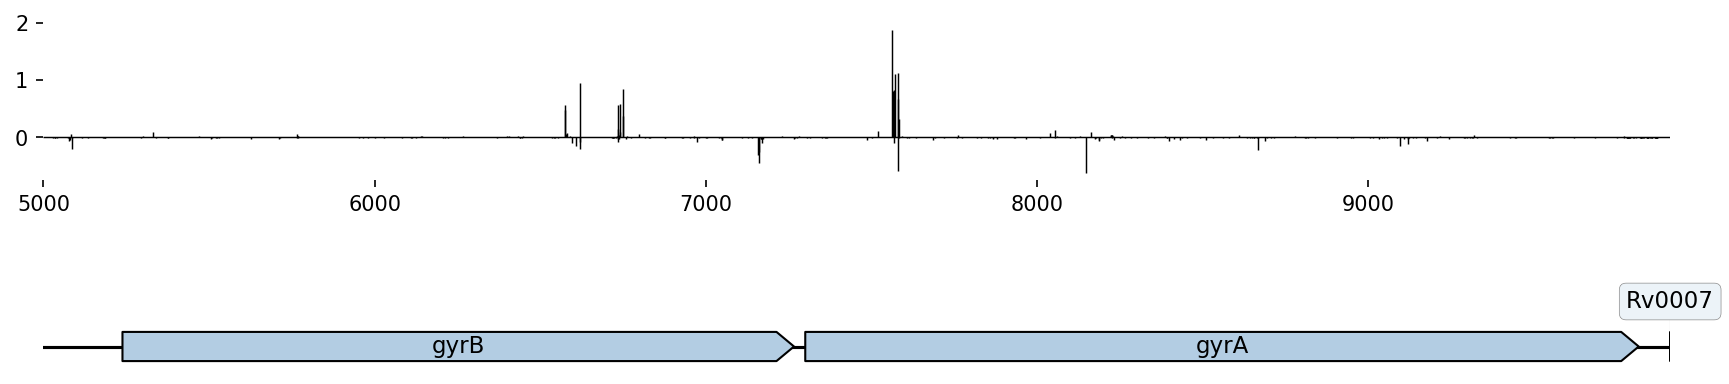

In [55]:
LEV_df, _ = generate_saliency_plots(drug="LEV",
                                    out_dir=os.path.join(results_path, "LEV_gyrBA_peptide_lineage"),
                                    locus_list=["gyrBA"],
                                    fasta_dir=data_path,
                                    cat_to_check=["1", "2"],
                                    binary=False,
                                    save=True,
                                    significance=True,
                                    sig_thresh=0.05,
                                  )

LEV_scores = sparse.load_npz(os.path.join(results_path, "LEV_gyrBA_peptide_lineage/saliency/quant/genetic_scores_unpooled_nuc.npy.npz")).todense()

In [164]:
LEV_gene_peptide_lengths = pd.read_csv(os.path.join(results_path, "LEV_gyrBA", "gene_peptide_lengths.csv"))
df_LEV = pd.read_csv(os.path.join(data_path, "LEV", "data_for_model.csv"))

In [166]:
LEV_gene_peptide_lengths.query("gyrA_length < 838")

,Unnamed: 0,gyrB_length,gyrA_length
115,ERR4810881,675,836
1553,ERR4822407,675,819


In [168]:
df_LEV.query("ROLLINGDB_ID=='ERR4822407'")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,LEV,LEV_lower_bound,LEV_midpoint,LEV_upper_bound,LEV_quality,Path,Coll2014,Binary,Lineage,category
1553,ERR4822407,ERS5312471,site.03.subj.UA21-2017.lab.UA21-2017.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.25,0.12,0.185,0.25,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_test_set


In [ ]:
bcftools filter -i "POS >= 4998 & POS <= 9913" /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/ERR4822407/pilon/ERR4822407.eff.vcf

In [ ]:
LEV_df.query("Pos==7585")

In [ ]:
MXF_isolate_variants = pd.read_csv(os.path.join(data_path, "MXF", "isolate_variants_fixed_annot.csv"))
MXF_isolate_variants.Isolate.nunique()

In [ ]:
MXF_isolate_variants.query("POS==7585")

In [ ]:
# gyrA_p.Ser95Thr
pos = 7585
idx = LEV_gyrBA_lineage_df.query("Pos==@pos").index.values[0] 
print(f"Ref: {MXF_gyrBA_seqDict['gyrBA'].loc['MT_H37Rv', pos]}")
scores = np.max(LEV_gyrBA_lineage_scores[:, :, idx, 0], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

In [ ]:
# Ala90: The only variant at 7570 is C>T, which is A90V (1. Assoc w R)
# A90G (C>G) is a category 4) Not assoc w R - interim variant
pos = 7564
idx = LEV_gyrBA_lineage_df.query("Pos==@pos").index.values[0] 
print(f"Ref: {MXF_gyrBA_seqDict['gyrBA'].loc['MT_H37Rv', pos]}")
scores = np.max(LEV_gyrBA_lineage_scores[:, :, idx, 0], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), scores))

In [ ]:
LEV_gyrBA_lineage_df.query("Pos==@pos")

In [ ]:
get_codon_from_seq(h37Rv_seq.seq, 88, 7302, 9818, '+')

In [ ]:
MXF_results.query("mutation=='gyrA_p.Gly88Ala'")

In [ ]:
MXF_results = pd.read_csv("/home/sak0914/who-analysis/results/FINAL/Moxifloxacin.csv")

In [ ]:
Seq('GGC').translate(), Seq('GCC').translate()

In [ ]:
def get_lengths(drug):

    regression_saliency_df = pd.read_csv(f"../regression/{drug}_saliency.csv")

    a = len(regression_saliency_df.query("~feature.str.contains('lineage')"))
    b = len(regression_saliency_df.query("~feature.str.contains('lineage') & pval < 0.05"))
    print(a, b, b/a)

# Indels with High Positive Scores

In [ ]:
RIF_isolate_variants.query("Isolate=='ERR4828591'")

In [ ]:
df_rif.query("ROLLINGDB_ID=='ERR4828591'")

In [ ]:
RIF_isolate_variants.query("POS==759648")

In [ ]:
RIF_isolate_variants.query("POS in [761097, 761102, 761106, 761813]").drop_duplicates("mutation").sort_values("POS")

In [ ]:
pos = 761106
idx = RIF_rpoBC_df.query("Pos==@pos").index.values[0] 
print(f"Ref: {rpoBC_seqDict['rpoBC'].loc['MT_H37Rv', pos]}")
max_scores = np.max(RIF_rpoBC_scores[:, :, idx, 0], axis=0)
dict(zip(BASE_TO_COLUMN.keys(), max_scores))

In [ ]:
MXF_pred = pd.read_csv("../analysis/Moxifloxacin/insilico_mutagenesis/gyrBA_WHO_predictions.csv")

MXF_pred = plot_pred_MIC_by_saliency("MXF", MXF_pred, MXF_gyrBA_lineage_df, gyrBA_seqDict['gyrBA'], MXF_gyrBA_lineage_scores, saveName="../analysis/Moxifloxacin/insilico_mutagenesis/predictions_vs_saliency.png")

In [ ]:
pos = 6742
print(f"Ref: {gyrBA_seqDict['gyrBA'].loc['MT_H37Rv', pos]}")
idx = MXF_gyrBA_lineage_df.query("Pos==@pos").index.values[0] 
max_scores = np.max(MXF_gyrBA_lineage_scores[:, :, idx, 0], axis=0)
max_scores_dict = dict(zip(BASE_TO_COLUMN.keys(), max_scores))
max_scores_dict

# Lineage Saliency Plots

In [162]:
def generate_lineage_saliency_plot(drug, drug_abbr, out_dir, binary_thresh, genes_lst, sig_thresh=0.2, significance=True, binary=False, savefName=None):

    df_phenos = pd.read_csv(os.path.join(data_path, drug_abbr, "data_for_model.csv"))
    df_phenos["log2_MIC"] = np.log2(df_phenos[f"{drug_abbr}_midpoint"])
    mean_log_mic = np.mean(df_phenos["log2_MIC"])
    print(f"Mean MIC: {df_phenos[f'{drug_abbr}_midpoint'].mean()}, Mean log2-MIC: {mean_log_mic}")
    
    
    ################################### STEP 1: MAKE LINEAGE MATRIX ###################################
    
    
    lineages = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])
    lineages.columns = lineages.columns.astype(int)
    assert len(np.unique(lineages.values)) == 2
    assert np.min(lineages.values) == 0

    # get only the training or testing set and subset the lineage matrix too
    lineages = lineages.loc[df_phenos["ROLLINGDB_ID"]]
    
    if binary:
        saliency_dir = os.path.join(out_dir, "saliency/binary")
    else:
        saliency_dir = os.path.join(out_dir, "saliency/quant")
        
    # get lineage scores for the primary model
    lineage_scores = np.load(os.path.join(saliency_dir, "mlp_scores.npy"))
    
    # create a dataframe with lineages, scores, and average log-MIC of isolates
    lineage_scores_df = pd.DataFrame({"position": list(genes_lst) + list(lineages.columns), 
                                      "Max": lineage_scores.max(axis=0), 
                                      "Min": lineage_scores.min(axis=0)
                                     })
    
    lineage_scores_df = lineage_scores_df.merge(coll_2014[["#lineage", "position"]], on="position")
    lineage_scores_df.rename(columns={"#lineage":"Lineage"}, inplace=True)
    lineage_scores_df["Lineage"] = [val.replace("lineage", "") for val in lineage_scores_df["Lineage"].values]
    
    
    ################################### STEP 2: COMPUTE AVERAGE MIC OF EACH LINEAGE DIVIDED BY AVERAGE OF THE WHOLE DATASET ###################################


    lineage_scores_df['Mean_log2_MIC'] = mean_log_mic
    
    # add log2-MIC to get averaged per lineage later
    lineages = lineages.merge(df_phenos[["ROLLINGDB_ID", "log2_MIC"]].set_index("ROLLINGDB_ID"), left_index=True, right_index=True)

    # insilico_lineage_predictions = pd.read_csv(f"../analysis/{drug}/insilico_mutagenesis/lineage_predictions.csv")
    # lineage_scores_df = lineage_scores_df.merge(insilico_lineage_predictions, on="Lineage", how="inner")

    for i, row in lineage_scores_df.iterrows():

        # add average log2-MIC of isolates with that SNP
        log2_MIC = lineages.loc[lineages[row["position"]]==1]["log2_MIC"].mean()
        lineage_scores_df.loc[i, ["log2_MIC", "MIC"]] = [log2_MIC, np.exp2(log2_MIC)]
    
        # then perform a hypothesis test for MIC enrichment (greater or less than the mean)
        pos, lineage = str(row["position"]), row["Lineage"]

        isolates_in_lineage = lineage_mat.loc[df_phenos["ROLLINGDB_ID"].values].loc[lineage_mat[pos]==1].index.values

        # hypothesis test to compare mean of isolates in a particular lineage to the entire dataset
        if len(isolates_in_lineage) > 0:

            if log2_MIC > mean_log_mic:
                alt = "greater"
            else:
                alt = "less"

            mu_stat, mu_pval = st.mannwhitneyu(df_phenos.query("ROLLINGDB_ID in @isolates_in_lineage")[f"{drug_abbr}_midpoint"].values, 
                                               df_phenos[f"{drug_abbr}_midpoint"].values,
                                               alternative=alt,
                                              )

            lineage_scores_df.loc[i, "MIC_pval"] = mu_pval
        
        else:
            lineage_scores_df.loc[i, "MIC_pval"] = np.nan
        
        
    ################################### STEP 3: GET P-VALUES FOR USING PERMUTATION MODEL SCORES ###################################
    

    # get permutation score results
    if significance:

        lineage_scores_paths = glob.glob(os.path.join(saliency_dir, "permutation_test/mlp_scores*.npy"))
        assert len(lineage_scores_paths) == 10

        lineage_permute_max = [pd.Series(np.load(scores_path).max(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_max = pd.concat(lineage_permute_max, axis=1).values

        lineage_permute_min = [pd.Series(np.load(scores_path).min(axis=0)) for scores_path in lineage_scores_paths]
        lineage_permute_min = pd.concat(lineage_permute_min, axis=1).values

        # get p-values from the permutation test
        for i, row in lineage_scores_df.iterrows():

            # for scores of 0, the p-value is often 0 because all the permuted values are also 0. This is a misleading p-value, so ignore them
            if row["Max"] > 0:
                lineage_scores_df.loc[i, "Max_pval"] = np.mean(lineage_permute_max[i, :] > row["Max"])
            else:
                lineage_scores_df.loc[i, "Max_pval"] = np.nan

            if row["Min"] < 0:
                lineage_scores_df.loc[i, "Min_pval"] = np.mean(lineage_permute_min[i, :] < row["Min"])
            else:
                lineage_scores_df.loc[i, "Min_pval"] = np.nan

        # _, mic_bh_pvals, _, _ = sm.multipletests(lineage_scores_df["MIC_pval"], method='fdr_bh', is_sorted=False, returnsorted=False)
        # lineage_scores_df["BH_MIC_pval"] = mic_bh_pvals
        lineage_scores_df["Bonferroni_MIC_pval"] = lineage_scores_df["MIC_pval"] * len(lineage_scores_df.loc[~pd.isnull(lineage_scores_df["MIC_pval"])])
        
        # assert len(lineage_scores_df.query("MIC_pval > BH_MIC_pval")) == 0
        assert len(lineage_scores_df.query("MIC_pval > Bonferroni_MIC_pval")) == 0
        
        significant_lineages = lineage_scores_df.query("(Max_pval < @sig_thresh & Max > 0) | (Min_pval < @sig_thresh & Min < 0)").reset_index(drop=True)

        # remove lineages where both are significant
        # significant_lineages = significant_lineages.query("~(Max_pval < @sig_thresh & Min_pval < @sig_thresh)")
        
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages are significant")

    else:
        significant_lineages = lineage_scores_df.query("Max > 0 | Min < 0")
        print(f"{len(significant_lineages)}/{len(lineage_scores_df)} lineages have a non-zero score")

    # print(f"{len(significant_lineages.query('Bonferroni_MIC_pval < @sig_thresh'))}/{len(significant_lineages)} saliency-significant lineages have average MICs significantly different from the mean")
    # print(f"{len(significant_lineages.query('Bonferroni_MIC_pval < @sig_thresh'))}/{len(significant_lineages)} saliency-significant lineages have average MICs significantly different from the mean")

        
    ################################### STEP 4: CREATE AN AGGREGATE SALIENCY SCORE FOR EACH LINEAGE ###################################
    
    
    # combine Max and Min scores, into a single array, depending on the site
    for i, row in significant_lineages.iterrows():
        
        if significance:
              
            if row["Max_pval"] < sig_thresh:

                # if Max is significant, but not Min
                if pd.isnull(row["Min_pval"]) or row["Min_pval"] >= sig_thresh:
                    significant_lineages.loc[i, "plot_score"] = row["Max"]
                    significant_lineages.loc[i, "plot_score_pval"] = row["Max_pval"]

                # if both are significant, take the average
                else:
                    significant_lineages.loc[i, "plot_score"] = np.mean([row["Max"], row["Min"]])

                    # arbitrarily take one of the p-values
                    significant_lineages.loc[i, "plot_score_pval"] = row["Max_pval"]

            # if Max is not significant, but Min is
            elif row["Min_pval"] < sig_thresh:
                significant_lineages.loc[i, "plot_score"] = row["Min"]
                significant_lineages.loc[i, "plot_score_pval"] = row["Min_pval"]

            # there's no else because we already filtered to keep lineages that are significant in at least Max or Min
            else:
                continue
                
        else:
            if row["Max"] > np.abs(row["Min"]):
                significant_lineages.loc[i, "plot_score"] = row["Max"]
                significant_lineages.loc[i, "plot_score_pval"] = row["Max_pval"]
            else:
                significant_lineages.loc[i, "plot_score"] = row["Min"]
                
            
    
    ################################### STEP 5: FIT A LINEAR REGRESSION TO PLOT A LINE OF BEST FIT ###################################
    

    significant_lineages_MICs = significant_lineages.query('plot_score_pval < 0.05 & Bonferroni_MIC_pval < 0.05 & ((plot_score > 0 & log2_MIC > Mean_log2_MIC) | (plot_score < 0 & log2_MIC < Mean_log2_MIC))')
    print(f"{len(significant_lineages_MICs)} lineages have a significant saliency score and an average log2_MIC significantly different from the mean")

    # fit a linear regression
    yvar = "log2_MIC"

    if len(significant_lineages_MICs) == 0:
        plot_df = significant_lineages.copy()
    else:
        plot_df = significant_lineages_MICs.copy()
    
    X = plot_df["plot_score"].values.reshape(-1, 1)
    y = plot_df[yvar]

    linReg = LinearRegression(fit_intercept=True)
    linReg.fit(X, y)
    yhat = linReg.predict(X)
    print(f"Predicted log2-MIC for saliency = 0: {linReg.predict(np.array([0]).reshape(-1, 1))}")
    
    fig, ax = plt.subplots(figsize=(4, 4))
    plt.plot(np.squeeze(X), yhat, color="tomato", linewidth=0.5, zorder=1, )#label=f"y = {np.round(linReg.intercept_, 2)} + {np.round(linReg.coef_[0], 2)}x")
    
    sns.scatterplot(data=plot_df, x="plot_score", y=yvar, ax=ax, s=25, linewidth=0.5, edgecolor="black", zorder=2)

    right_adj = 0.025
    up_adj = 0.05
    
    label_thresh = 0
    
    for i, row in plot_df.iterrows():
        
        ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
            
        # if drug_abbr == "RIF" and row["Lineage"] == "4**":
        #     ax.text(row["plot_score"] + right_adj, row[yvar] - 0.15, row["Lineage"], color='black', fontsize=6)
        # elif drug_abbr == "MXF":
        #     if row["Lineage"] == "2.2":
        #         ax.text(row["plot_score"] - 0.1, row[yvar] + up_adj*1.5, row["Lineage"], color='black', fontsize=6)
        #     elif row["Lineage"] == "1.1":
        #         ax.text(row["plot_score"] + right_adj*2, row[yvar] - up_adj, row["Lineage"], color='black', fontsize=6)
        #     elif row["Lineage"] == "4.1.1":
        #         ax.text(row["plot_score"] + right_adj + 0.01, row[yvar] - up_adj, row["Lineage"], color='black', fontsize=6)
        #     elif row["Lineage"] in ["1.2.1", "4.1.2.1"]:
        #         ax.text(row["plot_score"] + right_adj*1.5, row[yvar] - up_adj*2, row["Lineage"], color='black', fontsize=6)
        #     elif row["Lineage"] in ["2.2.2", "4.6.1.2", "4.6.1", "1.1.1", "1.1.2"]:
        #         ax.text(row["plot_score"] + right_adj*1.5, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
        #     else:
        #         ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
        # else:
        #     ax.text(row["plot_score"] + right_adj, row[yvar] + up_adj, row["Lineage"], color='black', fontsize=6)
        
    #plt.scatter(0, mean_log_mic, label="Average log2-MIC", marker="*", color="yellow", edgecolor="black", linewidth=0.5, s=40, zorder=3)
    # plt.axhline(y=mean_log_mic, linestyle='--', linewidth=0.5, color='black', label=f'Avg. = {np.round(mean_log_mic, 2)}')
    
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.yticks(ticks=ax.get_yticks(), labels=np.round(np.exp2(ax.get_yticks()), 2))
    plt.ylabel("Average MIC", fontsize=8)
    
    # plt.legend(fontsize=6, loc="lower right")
    plt.xlabel("Saliency Score", fontsize=8)
    sns.despine()
    
    corr_results = st.spearmanr(np.squeeze(X), y)
    
    plt.title(f"{drug} Model, Spearman R = {np.round(corr_results[0], 2)}, pval = {np.round(corr_results[1], 2)}", fontsize=10)
    
    if savefName is None:
        plt.show()
    else:
        plt.savefig(savefName, dpi=300)
        
    return significant_lineages

Mean MIC: 0.42809763394071254, Mean log2-MIC: -3.0667314626957918
58/62 lineages are significant
12 lineages have a significant saliency score and an average log2_MIC significantly different from the mean
Predicted log2-MIC for saliency = 0: [-3.17617492]


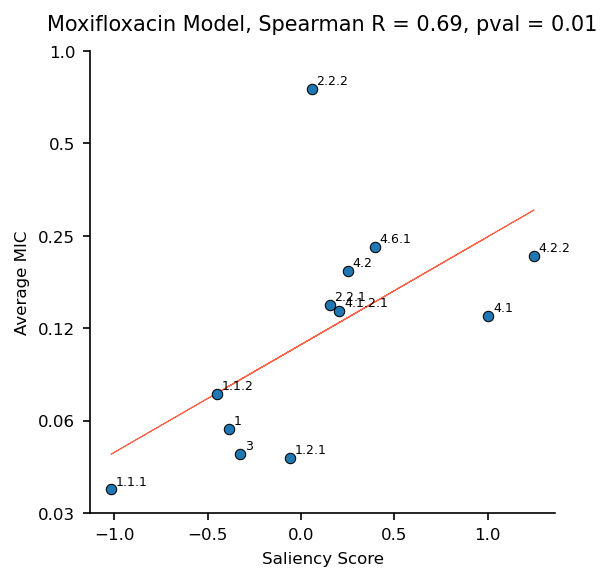

In [163]:
MXF_lineage_scores_df = generate_lineage_saliency_plot("Moxifloxacin",
                                                        "MXF", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_gyrBA_peptide_lineage", 
                                                       binary_thresh=0.5,
                                                       genes_lst=pd.read_csv(os.path.join(results_path, "MXF_gyrBA", "gene_peptide_lengths.csv"), index_col=[0]).columns,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       #savefName="../analysis/MXF/insilico_mutagenesis/lineage_scatter.png"
                                                     )

Mean MIC: 1.0208727142857144, Mean log2-MIC: -1.2614637523802692
41/62 lineages are significant
9 lineages have a significant saliency score and an average log2_MIC significantly different from the mean
Predicted log2-MIC for saliency = 0: [-1.64806353]


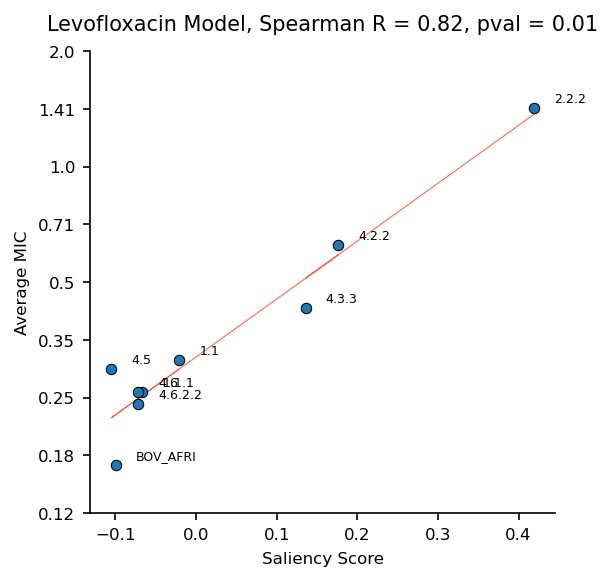

In [160]:
LEV_lineage_scores_df = generate_lineage_saliency_plot("Levofloxacin",
                                                        "LEV", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/LEV_gyrBA_peptide_lineage", 
                                                       binary_thresh=1,
                                                       genes_lst=pd.read_csv(os.path.join(results_path, "LEV_gyrBA", "gene_peptide_lengths.csv"), index_col=[0]).columns,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       #savefName="../analysis/Moxifloxacin/insilico_mutagenesis/lineage_scatter.png"
                                                     )

Mean MIC: 6.394668370181091, Mean log2-MIC: -0.9397099873389678
49/62 lineages are significant
15 lineages have a significant saliency score and an average log2_MIC significantly different from the mean
Predicted log2-MIC for saliency = 0: [-1.36479492]


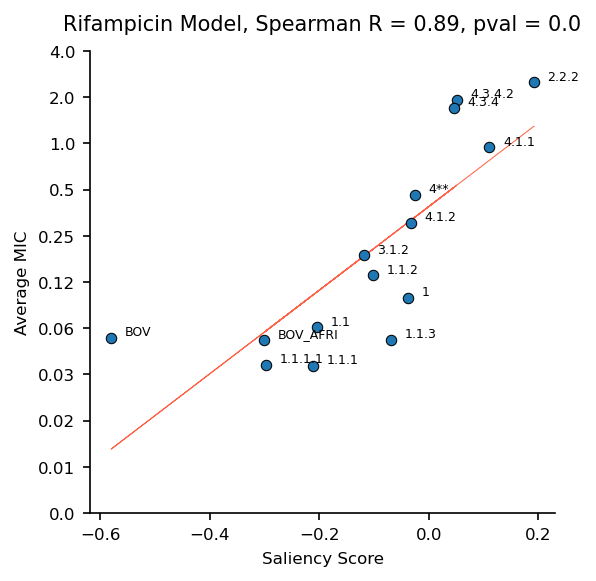

In [157]:
RIF_lineage_scores_df = generate_lineage_saliency_plot("Rifampicin",
                                                        "RIF", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/RIF_rpoABC_peptide_lineage", 
                                                       binary_thresh=0.5,
                                                       genes_lst=pd.read_csv(os.path.join(results_path, "RIF_rpoABC", "gene_peptide_lengths.csv"), index_col=[0]).columns,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       #savefName="../analysis/Moxifloxacin/insilico_mutagenesis/lineage_scatter.png"
                                                     )

In [ ]:
RIF_lineage_scores_df.query("Lineage in ['1', 'BOV_AFRI', '2.2.1', 'BOV']")

In [ ]:
np.exp2(-0.93971)

Mean MIC: 217.8448275862069, Mean log2-MIC: 6.441008957053313
37/62 lineages are significant
0 lineages have a significant saliency score and an average log2_MIC significantly different from the mean
Predicted log2-MIC for saliency = 0: [5.89046059]


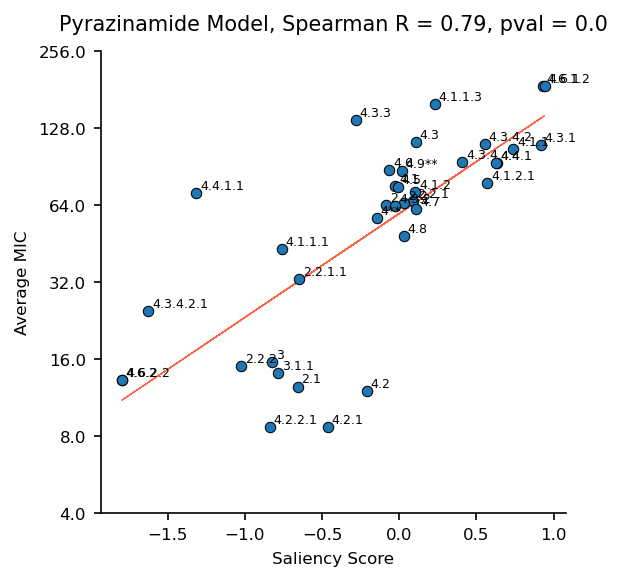

In [156]:
PZA_lineage_scores_df = generate_lineage_saliency_plot("Pyrazinamide",
                                                        "PZA", 
                                                       "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/PZA_4Loci_peptide_lineage", 
                                                       binary_thresh=100,
                                                       genes_lst=pd.read_csv(os.path.join(results_path, "PZA_4Loci", "gene_peptide_lengths.csv"), index_col=[0]).columns,
                                                       sig_thresh=0.05,
                                                       significance=True,
                                                       binary=False, 
                                                       #savefName="../analysis/Moxifloxacin/insilico_mutagenesis/lineage_scatter.png"
                                                     )

Index(['Rv2041c_length', 'Rv2042c_length', 'pncA_length', 'Rv2044c_length',
       'lipT_length', 'Rv3599c_length', 'Rv3600c_length', 'panD_length',
       'panC_length', 'Rv3603c_length', 'rpsA_length', 'coaE_length',
       'clpC1_length'],
      dtype='object')

# Is MIC Significantly Elevated in Certain Lineages

In [ ]:
RIF_sig_lineage_scores_df.query("Lineage in ['4.2.1', '2.2.1']")

In [ ]:
RIF_sig_lineage_scores_df.query("BH_MIC_enrich_pval < 0.05")

In [ ]:
# nice! does not co-occur with canonical gyrBA mutations
plot_variant_mics("gyrBA", 7566, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_7566_mic_dist.png")

In [ ]:
# too few isolates: only 5 with gyrBA or the variant at all. Also not convincing with the shift
# plot_variant_mics("gyrBA", 7521, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
# not super convincing. 22 total isolates, but gyrBA variants seem to be higher
# 6735, 6737, 6749
plot_variant_mics("gyrBA", 6735, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
plot_variant_mics("gyrBA", 8164, moxi_gyrBA_seq_dict, df_moxi, isolates_with_gyrBA_mut, title="../Figures/gyrBA_8164_mic_dist.png")

# Moxifloxacin Multiloci Models

In [ ]:
# moxi_gyrBA_6Loci_df, moxi_gyrBA_6Loci_seq_dict = generate_saliency_plots("config_moxi_6Loci.yaml",
#                                                              ["MXF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

# Bedaquiline

In [ ]:
# bdq_no_lineage_df, bdq_no_lineage_seq_dict = generate_saliency_plots("config_bdq_old.yaml",
#                                                              ["BDQ"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
who_single_drug = who_variants.query("drug=='RIF'")

who_pos = who_single_drug["genome_index"].str.split(",", expand=True)
who_pos.columns = ["pos1", "pos2"]

who_single_drug = pd.concat([who_single_drug, who_pos], axis=1).reset_index(drop=True)
print(who_single_drug.shape)

In [ ]:
for i, row in who_single_drug.iterrows():
    
    if not pd.isnull(row["pos2"]):
        
        # duplicate the row and make pos1 to pos2 in the duplicate
        add_row = who_single_drug.iloc[i, :]
        add_row["pos1"] = row["pos2"]
        
        who_single_drug = pd.concat([who_single_drug, pd.DataFrame(add_row).T], axis=0)
        
who_single_drug = who_single_drug.reset_index(drop=True)
del who_single_drug["pos2"]
del who_single_drug["genome_index"]
print(who_single_drug.shape)
who_single_drug.rename(columns={"pos1": "Pos"}, inplace=True)
who_single_drug["Pos"] = who_single_drug["Pos"].astype(float).astype(object)

In [ ]:
# get all sites with positive saliency scores
rif_resistance_analysis = rif_rpoBC_df.query("Max > 0 & max_pVal < 0.05").merge(who_single_drug, on="Pos", how="outer").sort_values("Max", ascending=False)

rif_resistance_analysis = rif_resistance_analysis.query("gene in ['rpoB', 'rpoC']").reset_index(drop=True)

del rif_resistance_analysis["Unnamed: 0"]
print(rif_resistance_analysis.shape)

#new_pos = rif_resistance_analysis.query("confidence in ['3) Uncertain significance', '5) Not assoc w R']")
new_pos = rif_resistance_analysis.loc[(~pd.isnull(rif_resistance_analysis["Max"])) & (rif_resistance_analysis["confidence"] == '3) Uncertain significance')]

print(new_pos.shape)

In [ ]:
for i, row in new_pos.iterrows():
    
    ref = rif_rpoBC_seq_dict["rpoBC"].loc["MT_H37Rv", row["Pos"]]
    alt = rif_rpoBC_seq_dict["rpoBC"][row["Pos"]] != ref
    new_pos.loc[i, "Num_Isolates"] = sum(alt)
    
# new_pos = new_pos.query("Num_Isolates > 5").reset_index(drop=True)
new_pos["Num_Isolates"] = new_pos["Num_Isolates"].astype(int) 
print(new_pos.shape)

In [ ]:
new_pos.sort_values(["Num_Isolates", "Max"], ascending=False)

In [ ]:
drug = "RIF"
locus = "rpoBC"
pos = 761880.0
cc = 0.5

for _, row in new_pos.drop_duplicates("Pos").sort_values(["Num_Isolates", "Max"], ascending=False).iterrows():
    plot_variant_mics(drug, locus, row["Pos"], rif_rpoBC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_df, rif_rpoABC_seq_dict = generate_saliency_plots("config_rif_multiLoci.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
# drug = "RIF"
# locus = "rpoA"
# pos = 3878575.0
# cc = 0.5

# plot_variant_mics(drug, locus, pos, rif_rpoABC_seq_dict, df_rif, isolates_with_rpoBC_mut, cc, title=None)

In [ ]:
# rif_rpoABC_Rv2752c_df, rif_rpoABC_Rv2752c_seq_dict = generate_saliency_plots("config_rif.yaml",
#                                                                              ["RIF"],
#                                                                              cat_to_check=["1", "2"],
#                                                                              binary=False,
#                                                                              isolate_variants_df=None,
#                                                                              num_bootstrap=1, 
#                                                                              save=True
#                                                                             )

In [ ]:
# rif_rpoBC_lineage_df, rif_rpoBC_lineage_seq_dict = generate_saliency_plots("config_rif_lineage.yaml",
#                                                              ["RIF"],
#                                                              cat_to_check=["1", "2"],
#                                                              binary=False,
#                                                              isolate_variants_df=None,
#                                                              num_bootstrap=1, 
#                                                              save=True
#                                                             )

In [ ]:
def two_sample_mean_bootstrap(variant_mics, no_variant_mics, num_bootstrap=1000):
    '''
    Want log2(fold change) > 1. 
    '''
    
    if len(variant_mics) > 0 and len(no_variant_mics) > 0:
        bs_res = []
        #test_stat = np.mean(variant_mics) - np.mean(no_variant_mics)
        test_stat = np.log2(np.mean(variant_mics) / np.mean(no_variant_mics))

        # do bootstrapping of difference in means. Randomly sample isolates from the two groups, then compute the mean difference in MIC between them
        for _ in range(num_bootstrap):

            # draw bootstraps
            variant_sample = np.random.choice(variant_mics, np.max([len(variant_mics), num_bootstrap]), replace=True)
            no_variant_sample = np.random.choice(no_variant_mics, np.max([len(no_variant_mics), num_bootstrap]), replace=True)

            # get the test statistic and add it to a running list
            #stat = np.mean(variant_sample) - np.mean(no_variant_sample)
            stat = np.log2(np.mean(variant_sample) / np.mean(no_variant_sample))
            bs_res.append(stat)
    else:
        test_stat = np.nan
        bs_res = np.ones(num_bootstrap) * np.nan
        
    return test_stat, np.array(bs_res)

In [ ]:
def plot_variant_mics(drug, locus, variant, mat_seq_dict, df_phenos, isolates_with_canonical_mut, cc, title=None):
    
    # sns.color_palette("Set2").as_hex()[0]
    palette = "Set1"
    color_dict = {"no variants": sns.color_palette(palette).as_hex()[-1], 
                  "variant only": sns.color_palette(palette).as_hex()[1],
                  "canonical mut only": sns.color_palette(palette).as_hex()[4],
                  "canonical mut + variant": sns.color_palette(palette).as_hex()[0]
                 }
        
    ref = mat_seq_dict[locus].loc["MT_H37Rv", variant]
    isolates_with_variant = mat_seq_dict[locus].loc[mat_seq_dict[locus][variant] != ref, variant].index.values
    
    isolates_both = list(set(isolates_with_canonical_mut).intersection(isolates_with_variant))
    isolates_variant_only = list(set(isolates_with_variant) - set(isolates_with_canonical_mut))
    isolates_canonical_only = list(set(isolates_with_canonical_mut) - set(isolates_with_variant))
    
    isolates_nothing_1 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_both) - set(isolates_variant_only) - set(isolates_canonical_only))
    isolates_nothing_2 = list(set(df_phenos["ROLLINGDB_ID"]) - set(isolates_with_canonical_mut) - set(isolates_with_variant))
    assert len(isolates_nothing_1) == len(isolates_nothing_2) == len(set(isolates_nothing_1).intersection(isolates_nothing_2))
        
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_nothing_1), "Variant"] = 'no variants'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_both), "Variant"] = 'canonical mut + variant'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_variant_only), "Variant"] = 'variant only'
    df_phenos.loc[df_phenos["ROLLINGDB_ID"].isin(isolates_canonical_only), "Variant"] = 'canonical mut only'
                            
    # print("There are no isolates without canonical variants, but with the variant of interest")
    if ~('variant only' not in df_phenos["Variant"].value_counts().index.values):
        df_phenos["log-MIC"] = np.log(df_phenos[f"{drug}_midpoint"])
        if (len(df_phenos.query("Variant == 'variant only'")) > 0) & (len(df_phenos.loc[(df_phenos["Variant"] == 'variant only') & (df_phenos[f"{drug}_midpoint"] > cc)]) > 1):
            print(df_phenos.groupby("Variant")[f"{drug}_midpoint"].mean())
            print(df_phenos["Variant"].value_counts())

            fig, ax = plt.subplots(1, 1, figsize=(12, 4))
            g = sns.histplot(data=df_phenos, x="log-MIC", hue='Variant', 
                             stat='probability', common_norm=False, multiple='dodge', 
                             hue_order=["no variants", 'canonical mut only', "variant only", 'canonical mut + variant'], 
                             palette=color_dict, ax=ax)

            plt.xlabel("MIC (μg/mL)")
            plt.xticks(ticks=ax.get_xticks(), labels=np.round(np.exp(ax.get_xticks()), 2).astype(str))
            ax.set_title(f"{drug} MIC Distribution for Variants at Position {int(variant)}")

            sns.move_legend(ax, "upper left", title=None)
            sns.despine()

            if title is None:
                plt.show()
            else:
                plt.savefig(title, dpi=300)
        # else:
        #     print(f"There are no isolates with only a variant at {variant}")

In [ ]:
def filter_saliencies(saliency_df, mat_seq_dict, drug, df_phenos):
    
    # get positions with non-zero scores
    nonZero = saliency_df.query("Max != 0 | Min != 0")
    
    # find the number of isolates with 
    for i, row in nonZero.iterrows():
        df = mat_seq_dict[row["Gene"]]
        if len(df[row["Pos"]].unique()) > 1:
            nonZero.loc[i, "Variant"] = 1
        else:
            nonZero.loc[i, "Variant"] = 0

    nonZero_analysis = nonZero.query("Variant == 1").sort_values("Max", ascending=False)
    
    for i, row in nonZero_analysis.iterrows():

        gene = row["Gene"]
        pos = row["Pos"]
        ref = mat_seq_dict[gene].loc["MT_H37Rv", pos]

        isolates_with_variant = mat_seq_dict[gene].loc[mat_seq_dict[gene][pos] != ref, pos].index.values

        if len(isolates_with_variant) >= 5:
            phenos_variant = df_phenos.query("ROLLINGDB_ID in @isolates_with_variant")[f"{drug}_midpoint"].values
            phenos_no_variant = df_phenos.query("ROLLINGDB_ID not in @isolates_with_variant")[f"{drug}_midpoint"].values

            stat, bootstrap_reps = two_sample_mean_bootstrap(phenos_variant, phenos_no_variant, num_bootstrap=100)
            lower, upper = np.percentile(bootstrap_reps, q=[2.5, 97.5])

            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = stat, lower, upper
        else:
            nonZero_analysis.loc[i, ["log2_FC", "log2_FC_LB", "log2_FC_UB"]] = np.nan, np.nan, np.nan
            
    return nonZero_analysis.dropna(axis=0, how="any")

In [ ]:
df_moxi.query("gyrBA_mut==0").to_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv", index=False)

In [ ]:
test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220929_no_gyrBACanonicalMut.csv")

In [ ]:
test.shape

In [ ]:
4819/(4819+1198)

In [ ]:
1198/(4819+1198)

In [ ]:
df_moxi.query("gyrBA_mut==0").groupby("category")["MOXI_midpoint"].mean()

In [ ]:
df_moxi.query("ROLLINGDB_ID not in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
df_moxi.query("ROLLINGDB_ID in @isolates_with_gyrBA_mut").MOXI_midpoint.max()

In [ ]:
#plot_variant_mics("Rv3361c_Rv3365c", 3774261, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4005357.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
#plot_variant_mics("Rv3561_Rv3565", 4004893.0, moxi_4Loci_seq_dict, df_moxi, isolates_with_gyrBA_mut)

In [ ]:
moxi_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/isolate_variants.csv")

# Moxifloxacin Multi-Loci

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv3361c_Rv3365c', 'Rv3561_Rv3565'] 
moxi_4loci_df, moxi_4Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220928_moxi_4Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

In [ ]:
locus_list = ['gyrBA', 'Rv0981_Rv0984', 'Rv2836c_Rv2837c', 'Rv3361c_Rv3365c', 'Rv0014c_Rv0015c', 'arfABC', 'phoPR', 'mbtK', 'Rv3561_Rv3565', 'stp', 'Rv0053_Rv0058', 'ligD_Rv0939'] 
# definitely remove: phoPR, stp, mbtK, Rv2836c_Rv2837c (dinF)
# next tier: arfABC, Rv0014c_Rv0015c

# generally good agreement between low saliency and not much contribution to MAE reduction

moxi_12loci_df, moxi_12Loci_seq_dict = generate_saliency_plots("MOXI", 
                                                                 locus_list, 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/20220907_moxi_12Loci", 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/fastas", 
                                                                 ["MXF"], 
                                                                 "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MOXI/20220902_data_clean.csv",
                                                                 cat_to_check=["1", "2"],
                                                                 isolate_variants_df=None,
                                                                 num_bootstrap=1000, 
                                                                 save=False
                                                                )

# Analysis of Positions from Multi-Gene Model

In [ ]:
def validate_with_MIC_dist(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=1000):
    
    # check for significantly positive confidence intervals for all 3 groups -- isolates with canonical gyrBA mutations, isolates without, and all isolates
    ci_no_gyrBA, ci_gyrBA = plot_variant_mics(locus, variant_col, mat_seq_dict, df_phenos, isolates_with_gyrBA_mut, num_bootstrap=num_bootstrap, plot=False)
    #ci_all = plot_variant_mics_full_dist(locus, variant_col, mat_seq_dict, df_phenos, plot=False)
    
    # if at least one of them is significantly positive, keep that variant    
    cis_lst = [ci_no_gyrBA, ci_gyrBA]
    
    sig_bool = False
    for ci in cis_lst:
        
        if ci[0] > 0 and ci[1] > 0:
            sig_bool = True
            break
            
    if sig_bool:
        return 1
    else:
        return 0

In [ ]:
def filter_saliencies_by_seq_quality(var, gene, seq_dict, isolate_variants_df):
    
    ref_allele = seq_dict[gene].loc["MT_H37Rv", var]
    alt_alleles = seq_dict[gene].loc[seq_dict[gene][var] != ref_allele, var].unique()
    
    if type(var) in [float, int]:
        print("Pos found")
        # more than half of the variants must have passed QC
        if isolate_variants_df.query("POS == @var").QC.fillna(0).mean() > 0.5:
            # print(isolate_variants_df.query("POS == @var").QC.value_counts())
            print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    elif var.isnumeric():
        print("Pos found")
        print(isolate_variants_df.query("POS == @var").Isolate.unique())
        
    # insertion relative to H37Rv
    else:  
        if ref_allele == '-':
            var_pos = np.where(seq_dict[gene].columns == var)[0][0]
            prev_pos = seq_dict[gene].columns[var_pos-1]
            
            if isolate_variants_df.query("POS == @prev_pos").QC.fillna(0).mean() > 0.5:
                # print(isolate_variants_df.query("POS == @var").QC.value_counts())
                print(isolate_variants_df.query("POS == @prev_pos").Isolate.unique())

## The next 2 cells aren't needed because they don't significantly improve interpretation of results

In [ ]:
# # Merging promoters for plus strand
# promoter_location_data1 = pd.read_csv("../inputs/promoters_plus_strand.csv")
# data = promoter_location_data1.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 74

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# print(len(data), len(output_data))
# promoter_location_data1= output_data

# # Merging promoters for minus strand
# promoter_location_data2 = pd.read_csv("../inputs/promoters_minus_strand.csv")
# data = promoter_location_data2.sort_values("upstream")[["downstream_gene", "position_upstream", "site", "upstream", "downstream"]]
# data = data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# output_data =  []
# tracked_row = list(data.iterrows())[0][1]
# current_end = 0

# for idx, row in data.iterrows():

#     if row.upstream <= current_end:
#         # merging triggered
#         current_end = row.downstream
#     else:
#         tracked_row["downstream"] = current_end
#         output_data.append(tracked_row)
#         tracked_row = row
#         current_end = row.downstream
        
# output_data = pd.DataFrame(output_data)  
# output_data = output_data.iloc[1::,]
# output_data = output_data.rename({
#     "upstream": "downstream",
#     "downstream": "upstream"
# }, axis = 1)
# print(len(data), len(output_data))
# promoter_location_data2= output_data

In [ ]:
# Add promoter annotations to genome
# H37Rv Genome

# for idx,row in promoter_location_data1.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.upstream, row.downstream, 1
#     ), feature_type="promoter")
    
# for idx,row in promoter_location_data2.iterrows():
#     #Plus strand promoters
#     annotate_biopython_record(record, location=(
#         row.downstream, row.upstream, -1
#     ), feature_type="promoter")